# FTIML Assignment 2: Fairness (10 points)

## Dataset: 2021 British Columnbia (Canada) Census data

The dataset represents the 2021 British Columbia (Canada) Census data. Each row describes the demographic and socioeconomic characteristics of an individual. The objective is to predict whether an individual's income exceeds 75K. These predictions will be used by a company that determines loan approvals based on your model's output. An individual's income may be influenced by their demographic and socioeconomic attributes. However, the company is legally prohibited from engaging in unfair treatment on the basis of "race, national or ethnic origin, colour, religion, age, sex, sexual orientation, gender identity or expression, marital status, family status, genetic characteristics, disability, or conviction for an offence for which a pardon has been granted or in respect of which a record suspension has been ordered", as outlined in the Canadian Human Rights Act. Your task is to analyze the fairness of your model's predictions and to apply techniques to improve the fairness of your models.

See for more information on the dataset "2021 Census Individuals PUMF User Guide.pdf". You are not required to read the entire document. 

Hint: Unavailable data is often encoded by 88888888 or 99999999.

## Deliverable:

A **.zip file** containing two elements: 
1. The **Jupyter notebook** you used for your analysis of Tasks a - d below (in ipynb).  
2. A **report of max. 4 pages** with the complete answers to the questions below (in pdf). 

**DEADLINE: Monday May 11, 2026 at 23:59.**

Note: All information in 2. needs to be contained in 1. (not necessarily vice versa).

Note: The grade for the assignment is primarily based on your presentation on May 12 and your report. The notebook serves as an add-on.


## Task a: Data Exploration
Before entering the analysis, spend some time to understand the data. 

* Which features do you expect to influence fairness?
* Define groups based on the sensitive feature(s) and visualize the data.
* Are there any inbalances? How might these affect your fairness analysis? 

Use graphs and/or tables, and write down your observations. 


## Task b: Explore Fairness
Take the outcomes of a black-box model (you may use the random forest model fitted below or for example a XGBoost model, neural network, ...) and an interpretable model of your choice and analyze their fairness across different protected groups.

*   Choose and report three group fairness metrics that are useful for the given context and report them.
*   Do you find evidence for biases in the models? Which group(s) appear to be at a disadvantage?
*   Are there any differences in fairness metrics between the black-box and interpretable models?

Use visualizations to support your analysis. Summarize the results in text. 


## Task c: Individual Fairness
Try to improve the fairness of your models using two individual fairness techniques.

Refer to the lecture slides and the notebook from the fairness tutorial for guidance on what is expected here.

Clearly state the techniques you are using and elaborate on their effects on the fairness of the models.


## Task d: Group Fairness
Try to improve the fairness metrics of your models using two group fairness techniques.

Explain why you choose the techniques you are using and elaborate on their effects on the fairness of the models.


# Preparations

## Install and load libraries

In [216]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

## Load and preprocess data
**Do not change this part**

In [218]:
data = pd.read_csv('data_donnees_2021_ind_BC.csv')
#print columns all column s
print(list(data.columns))

['PPSORT', 'ABOID', 'AGEGRP', 'AGEIMM', 'ATTSCH', 'BFNMEMB', 'BEDRM', 'CFSTAT', 'CHDBN', 'CIP2021', 'CIP2021_STEM_SUM', 'CMA', 'CONDO', 'COVID_ERB', 'COW', 'CQPPB', 'CfSize', 'ChldC', 'CitOth', 'Citizen', 'DIST', 'DPGRSUM', 'DTYPE', 'EFDecile', 'EFInc', 'EFInc_AT', 'EICBN', 'ETHDER', 'EfDIMBM_2018', 'EfSize', 'FOL', 'FPTWK', 'Gender', 'GENSTAT', 'GTRfs', 'HCORENEED_IND', 'HDGREE', 'HHSIZE', 'HHTYPE', 'HLMOSTEN', 'HLMOSTFR', 'HLMOSTNO', 'HLREGEN', 'HLREGFR', 'HLREGNO', 'IMMCAT5', 'IMMSTAT', 'JOBPERM', 'KOL', 'LFACT', 'LICO_BT', 'LICO_AT', 'LIPROGTYPE', 'LI_ELIG_OML_U18', 'LOCSTUD', 'LOC_ST_RES', 'LSTWRK', 'LWMOSTEN', 'LWMOSTFR', 'LWMOSTNO', 'LWREGEN', 'LWREGFR', 'LWREGNO', 'LoLIMA', 'LoLIMB', 'LOMBM_2018', 'MODE', 'MTNEn', 'MTNFr', 'MTNNO', 'MARSTH', 'Mob1', 'Mob5', 'NAICS', 'NOC21', 'NOS', 'OASGI', 'PKID25', 'PKID0_1', 'PKID15_24', 'PKID2_5', 'PKID6_14', 'PKIDS', 'POB', 'POBPAR1', 'POBPAR2', 'POWST', 'PR1', 'PR5', 'PRESMORTG', 'PRIHM', 'PWDUR', 'PWLEAVE', 'PWOCC', 'PWPR', 'REGIND', 'RE

In [219]:
# get features and target
AGEGRP = data['AGEGRP'] # this serves as an example, you can choose other sensitive attributes
X = pd.get_dummies(data.drop(columns=["75k"]))
y = data["75k"]

## Exploratory data analysis and feature engineering
Inspect the data and do some plots that help you understand the dataset here.

**Optional**: The dataset is already preprocessed. However, it might still pay off to invest some time in additional preprocessing here here (scaling, feature engineering, ...). This might improve model quality and help to rectify modeling errors.

**Note**: The data is imbalanced.

In [222]:
print(y.value_counts())

75k
0    44476
1    12014
Name: count, dtype: int64


In [223]:
import sweetviz as sv # pip install sweetviz    

fairness_vars = ['Gender', 'VISMIN', 'ABOID', 'AGEGRP', 'RELIGION_DER', 'MARSTH',
                 'ETHDER', 'IMMSTAT', 'GENSTAT', 'POB', 'POBPAR1', 'POBPAR2', 'Citizen']

report = sv.analyze(X[fairness_vars])
#report.show_notebook()

                                             |      | [  0%]   00:00 -> (? left)

## Train test split
We use stratification along the y feature to ensure that the training and the test set have a similar amount of positive and negative examples.

**Do not change the random seed here to ensure that all groups have the same test set**

In [225]:
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, AGEGRP, random_state=42, stratify=y)

## Fit Random Forest Model to Data

Below we train a random forest estimator as blackbox model for our problem.

**Note**: Hyperparameter tuning might take a while (especially when run online in Google Colab)

In [227]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

**Alternative**: Simply fit the model with the parameters found above

In [229]:
rf = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

### Analyze fit of the model


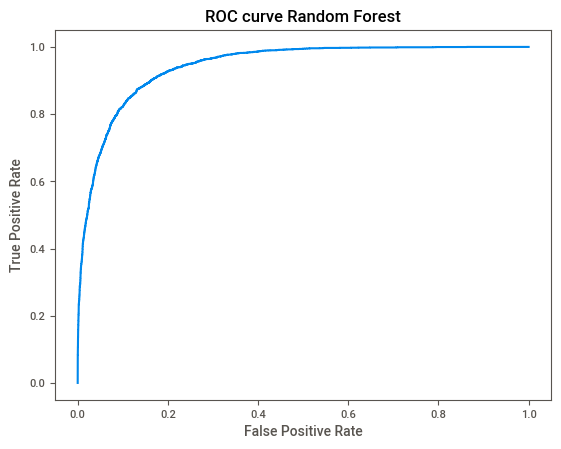

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     11119
           1       0.60      0.90      0.72      3004

    accuracy                           0.85     14123
   macro avg       0.78      0.87      0.81     14123
weighted avg       0.89      0.85      0.86     14123



In [231]:
# predict probabilities of readmission
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:,1]

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Random Forest')
plt.show()

# get classification report and tune threshold in such a way that recall is at least 0.9
threshold = 0.5
print(classification_report(y_test, y_pred > threshold))


In [232]:
print(f" In a group of 1000 individuals approximately {sum(y_pred > threshold) / len(y_pred) * 1000:.0f} have a salary higher than 75k. Amongst these ... \n \
      \t ... {sum((y_test == 1) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are correctly classified; \n \
      \t ... {sum((y_test == 0) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are classified as not having a salary higher than 75k. \n \n \
Additionally, we expect that there are {sum((y_test == 1) & (y_pred < threshold)) / len(y_pred) * 1000:.0f} individuals who have a salary higher than 75k but are not classified as such.")

 In a group of 1000 individuals approximately 320 have a salary higher than 75k. Amongst these ... 
       	 ... 192 are correctly classified; 
       	 ... 129 are classified as not having a salary higher than 75k. 
 
 Additionally, we expect that there are 21 individuals who have a salary higher than 75k but are not classified as such.


In [233]:
len(y_pred)

14123

## Task D - Group Fairness

In [313]:
from sklearn.metrics import confusion_matrix, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

### Data preparation

In [315]:
gender_labels  = {1: 'Woman+', 2: 'Man+'}
immstat_labels = {0: 'Immigrant/NPR', 1: 'Non-immigrant'}

# IMMSTAT setup 
data['IMMSTAT_binary'] = data['IMMSTAT'].map(lambda x: 1 if x == 1 else (0 if x in [2, 3] else np.nan))

# Gender
GENDER = data['Gender']
X = pd.get_dummies(data.drop(columns=["75k", "IMMSTAT_binary"]))
y = data["75k"]

# Test / Train set 
X_train, X_test, y_train, y_test, G_train, G_test = train_test_split(X, y, GENDER, random_state=42, stratify=y)
sens_im_train = data['IMMSTAT_binary'].loc[y_train.index].dropna()
sens_im_test  = data['IMMSTAT_binary'].loc[y_test.index].dropna()

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"\nGender distribution in test set:")
print(G_test.map(gender_labels).value_counts())
print(f"\nIncome prevalence by Gender:")
print(data.groupby(data['Gender'].map(gender_labels))['75k'].mean().rename('P(Y=1|A=a)').round(4))

print(f"\nIMMSTAT distribution in test set (after removing 88s, n={len(sens_im_test)}):")
print(sens_im_test.map(immstat_labels).value_counts())
print(f"\nIncome prevalence by IMMSTAT:")
print(data.groupby(data['IMMSTAT_binary'].map(immstat_labels))['75k'].mean().rename('P(Y=1|A=a)').dropna().round(4))

Train size: 42367 | Test size: 14123

Gender distribution in test set:
Gender
Woman+    7114
Man+      7009
Name: count, dtype: int64

Income prevalence by Gender:
Gender
Man+      0.2717
Woman+    0.1540
Name: P(Y=1|A=a), dtype: float64

IMMSTAT distribution in test set (after removing 88s, n=14098):
IMMSTAT_binary
Non-immigrant    9150
Immigrant/NPR    4948
Name: count, dtype: int64

Income prevalence by IMMSTAT:
IMMSTAT_binary
Immigrant/NPR    0.1857
Non-immigrant    0.2270
Name: P(Y=1|A=a), dtype: float64


### Baseline - Taken from Task B

In [317]:
# Baseline models — same hyperparameters as Task B
threshold_rf = 0.5
threshold_lr = 0.45

# Random Forest
rf = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf > threshold_rf).astype(int)

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr > threshold_lr).astype(int)

# Pipeline LR for ThresholdOptimizer
lr_pipe = Pipeline([('scaler', StandardScaler()),('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
lr_pipe.fit(X_train, y_train)

print(f"RF  accuracy: {accuracy_score(y_test, y_pred_rf):.4f}  "
      f"balanced: {balanced_accuracy_score(y_test, y_pred_rf):.4f}")
print(f"LR  accuracy: {accuracy_score(y_test, y_pred_lr):.4f}  "
      f"balanced: {balanced_accuracy_score(y_test, y_pred_lr):.4f}")

RF  accuracy: 0.8504  balanced: 0.8688
LR  accuracy: 0.8543  balanced: 0.8704


### Helper Functions

In [318]:
def find_best_threshold(y_true, y_prob):
    best_thresh, best_score = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.01):
        score = balanced_accuracy_score(y_true, (y_prob > t).astype(int))
        if score > best_score:
            best_score, best_thresh = score, t
    return best_thresh

def fairness_metrics(y_true, y_pred, sensitive, label="", group_labels=None):
    group_labels = group_labels or {}
    rows = []
    yt_vals = np.array(y_true) if not isinstance(y_true, np.ndarray) else y_true
    yp_vals = np.array(y_pred)
    s_vals  = np.array(sensitive)

    for group in sorted(np.unique(s_vals)):
        mask = s_vals == group
        yt, yp = yt_vals[mask], yp_vals[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            "Group":         group_labels.get(group, str(group)),
            "N":             mask.sum(),
            "Positive Rate": yp.mean(),
            "TPR":           tp / (tp + fn) if (tp + fn) > 0 else 0,
            "FPR":           fp / (fp + tn) if (fp + tn) > 0 else 0,
            "Precision":     tp / (tp + fp) if (tp + fp) > 0 else 0,
        })
    df = pd.DataFrame(rows).set_index("Group")

    dpd  = demographic_parity_difference(yt_vals, yp_vals, sensitive_features=s_vals)
    eod  = equalized_odds_difference(yt_vals, yp_vals, sensitive_features=s_vals)
    ppd  = df['Precision'].max() - df['Precision'].min()
    acc  = accuracy_score(yt_vals, yp_vals)
    bacc = balanced_accuracy_score(yt_vals, yp_vals)

    print(f"\n{'─'*65}")
    print(f"  {label}")
    print(f"{'─'*65}")
    print(f"  Accuracy          : {acc:.4f}  |  Balanced Accuracy: {bacc:.4f}")
    print(f"  DPD               : {dpd:.4f}")  
    print(f"  EOD               : {eod:.4f}")  
    print(f"  PPD               : {ppd:.4f}")  
    print(df.round(4).to_string())
    return df, {"DPD": dpd, "EOD": eod, "PPD": ppd, "Acc": acc, "BAcc": bacc}


def plot_group_roc(plots, main_title=""):
    fig, axes = plt.subplots(1, len(plots), figsize=(7*len(plots), 6))
    if len(plots) == 1:
        axes = [axes]
    colors = plt.cm.tab10.colors
    for ax, p in zip(axes, plots):
        yt = np.array(p['y_true'])
        yp = np.array(p['y_prob'])
        s  = np.array(p['sensitive'])
        gl = p.get('group_labels', {})
        for i, group in enumerate(sorted(np.unique(s))):
            mask = s == group
            fpr, tpr, _ = roc_curve(yt[mask], yp[mask])
            name = gl.get(group, str(group))
            ax.plot(fpr, tpr, color=colors[i],
                    label=f"{name} (AUC={auc(fpr,tpr):.3f})")
        ax.plot([0,1],[0,1],'k--',lw=0.8,label="Random")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(p['title'])
        ax.legend()
    if main_title:
        fig.suptitle(main_title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_tpr_fpr_grid(y_test, yb_base, yb_technique, sensitive, technique_name, group_labels=None):
    group_labels = group_labels or {}
    s_vals = np.array(sensitive)
    gl = [group_labels.get(g, str(g)) for g in sorted(np.unique(s_vals))]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Separation (TPR & FPR) — Before and After {technique_name}', fontsize=12, fontweight='bold')

    for row, (yb, title) in enumerate([
        (pd.Series(np.array(yb_base),      index=y_test.index), 'Baseline'),
        (pd.Series(np.array(yb_technique), index=y_test.index), technique_name)]):
        for col, metric in enumerate(['TPR', 'FPR']):
            ax = axes[row][col]
            vals = []
            for group in sorted(np.unique(s_vals)):
                mask = sensitive == group
                yt = y_test[mask].values
                yp = yb[mask].values
                tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
                vals.append(tp/(tp+fn) if metric=='TPR' and (tp+fn)>0
                            else fp/(fp+tn) if metric=='FPR' and (fp+tn)>0 else 0)
            gap = max(vals) - min(vals)
            bars = ax.bar(gl, vals, color=['#59a14f','#4e79a7'], edgecolor='white')
            ax.axhline(np.mean(vals), color='red', linestyle='--', lw=1.2, label=f'Mean={np.mean(vals):.3f}')
            ax.set_title(f'{title} — {metric} (gap={gap:.4f})')
            ax.set_ylabel(metric)
            ax.set_ylim(0, 1.1)
            ax.legend(fontsize=8)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.3f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_before_after(df_before, df_after, metrics, title,
                      sc_before=None, sc_after=None):
    fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        x = np.arange(len(df_before))
        ax.bar(x-0.2, df_before[metric], 0.4, label="Baseline",          color="steelblue", alpha=0.85)
        ax.bar(x+0.2, df_after[metric],  0.4, label="Technique applied", color="coral",     alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(df_before.index, rotation=30, ha='right')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    if sc_before is not None and sc_after is not None:
        fig2, axes2 = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))
        fig2.suptitle(f'{title} — Scalar Gaps', fontsize=11, y=1.02)
        scalar_metrics = ['BAcc', 'DPD', 'EOD', 'PPD']
        scalar_titles  = ['BAcc',
                          'DPD',
                          'EOD',
                          'PPD']
        for i, ax in enumerate(axes2):
            if i < len(scalar_metrics):
                metric = scalar_metrics[i]
                vals = [sc_before[metric], sc_after[metric]]
                bars = ax.bar([0, 1], vals, color=['steelblue','coral'], alpha=0.85, edgecolor='white', width=0.4)
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['Baseline','Technique applied'], rotation=30, ha='right')
                ax.set_ylabel(metric)
                ax.set_title(scalar_titles[i])
                for bar, v in zip(bars, vals):
                    ax.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+0.001,
                            f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
            else:
                ax.set_visible(False)
        plt.tight_layout()
        plt.show()


def print_fairness_summary(attr_name, sensitive, model_configs):
    for model_name, configs in model_configs:
        print('\n' + '='*70)
        print(f'SUMMARY: All fairness metrics — {attr_name}, {model_name}')
        print('='*70)
        print(f"{'Method':<25} {'Acc':>8} {'BAcc':>8} {'DPD':>8} {'EOD':>8} {'PPD':>8}")
        print('-'*70)
        for label, yt, yp in configs:
            groups = np.array(sensitive)
            precisions = []
            for g in np.unique(groups):
                mask = groups == g
                tn, fp, fn, tp = confusion_matrix(yt[mask], yp[mask], labels=[0,1]).ravel()
                precisions.append(tp/(tp+fp) if (tp+fp) > 0 else 0)
            acc  = accuracy_score(yt, yp)
            bacc = balanced_accuracy_score(yt, yp)
            dpd  = demographic_parity_difference(yt, yp, sensitive_features=sensitive)
            eod  = equalized_odds_difference(yt, yp, sensitive_features=sensitive)
            ppd  = max(precisions) - min(precisions)
            print(f'{label:<25} {acc:>8.4f} {bacc:>8.4f} {dpd:>8.4f} {eod:>8.4f} {ppd:>8.4f}')
        print()


def fairness_gap_plot(summary_df, title):
    n = len(summary_df)
    colors = (["steelblue", "coral", "seagreen"] * 4)[:n]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col in zip(axes, ["DPD", "EOD", "PPD"]):
        bars = ax.bar(range(n), summary_df[col].abs(),
                      color=colors, edgecolor="black", alpha=0.85)
        ax.set_xticks(range(n))
        ax.set_xticklabels(summary_df.index, rotation=35, ha="right", fontsize=8)
        ax.set_ylabel("Fairness Gap")
        ax.set_title(f"{col}")
        for bar, v in zip(bars, summary_df[col].abs()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')
        ax.legend(handles=[
            plt.Rectangle((0,0),1,1, color="steelblue", label="Baseline"),
            plt.Rectangle((0,0),1,1, color="coral",     label="Reweighing"),
            plt.Rectangle((0,0),1,1, color="seagreen",  label="ThresholdOptimizer")
        ], fontsize=8)
    plt.tight_layout()
    plt.show()

METRICS = ["Positive Rate", "TPR", "FPR", "Precision"]

### Baseline models + Group ROC curves


─────────────────────────────────────────────────────────────────
  Random Forest (Baseline) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8504  |  Balanced Accuracy: 0.8688
  DPD               : 0.1001
  EOD               : 0.0276
  PPD               : 0.1734
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2705  0.8832  0.1599     0.4990
Man+    7009         0.3705  0.9108  0.1671     0.6723

─────────────────────────────────────────────────────────────────
  Logistic Regression (Baseline) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8543  |  Balanced Accuracy: 0.8704
  DPD               : 0.1333
  EOD               : 0.0831
  PPD               : 0.1456
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2491  0.845

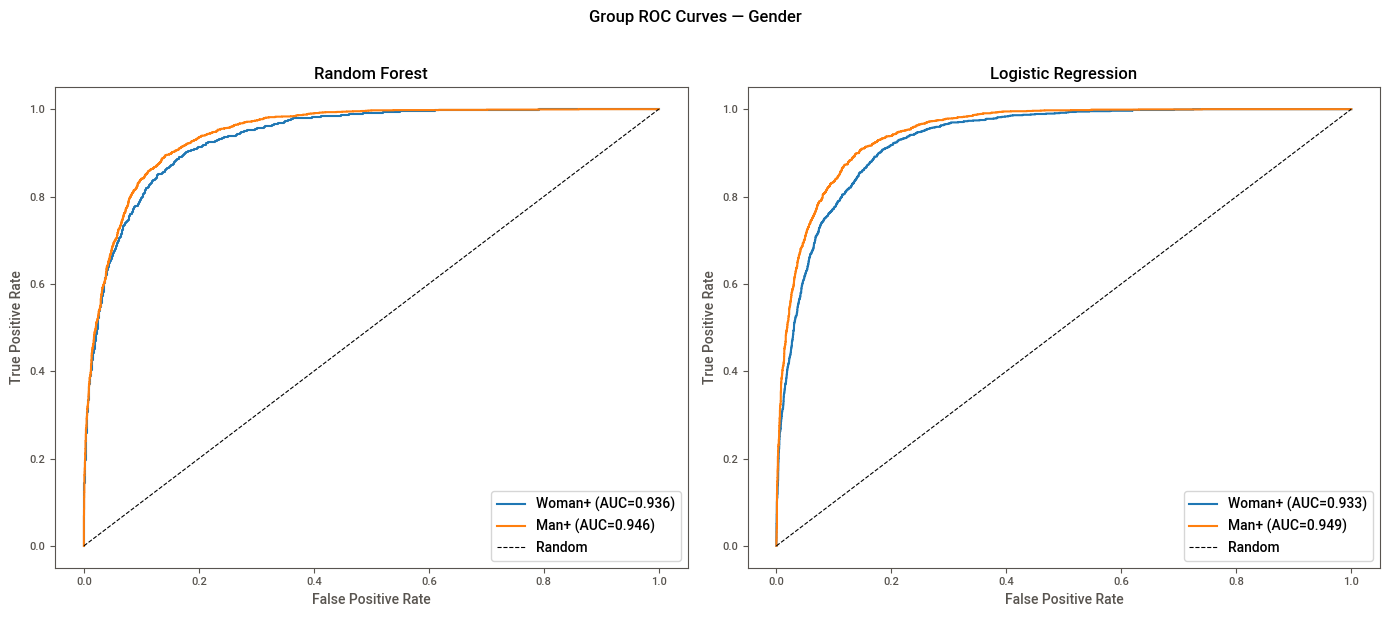

In [322]:
# Gender Baseline
df_base_rf_g, sc_base_rf_g = fairness_metrics(y_test.values, y_pred_rf, G_test, label="Random Forest (Baseline) | Gender", group_labels=gender_labels)
df_base_lr_g, sc_base_lr_g = fairness_metrics(y_test.values, y_pred_lr, G_test, label="Logistic Regression (Baseline) | Gender", group_labels=gender_labels)

plot_group_roc([dict(y_true=y_test,    y_prob=y_prob_rf,   sensitive=G_test, title="Random Forest",  group_labels=gender_labels),
    dict(y_true=y_test,    y_prob=y_prob_lr,   sensitive=G_test, title="Logistic Regression",  group_labels=gender_labels),], main_title="Group ROC Curves — Gender")


─────────────────────────────────────────────────────────────────
  Random Forest (Baseline) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8503  |  Balanced Accuracy: 0.8689
  DPD               : 0.0689
  EOD               : 0.0572
  PPD               : 0.0345
                  N  Positive Rate     TPR     FPR  Precision
Group                                                        
Immigrant/NPR  4948         0.2759  0.8615  0.1439     0.5744
Non-immigrant  9150         0.3448  0.9187  0.1748     0.6089

─────────────────────────────────────────────────────────────────
  Logistic Regression (Baseline) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8541  |  Balanced Accuracy: 0.8702
  DPD               : 0.0645
  EOD               : 0.0387
  PPD               : 0.0294
                  N  Positive Rate     TPR     FPR  Precision
Group                                               

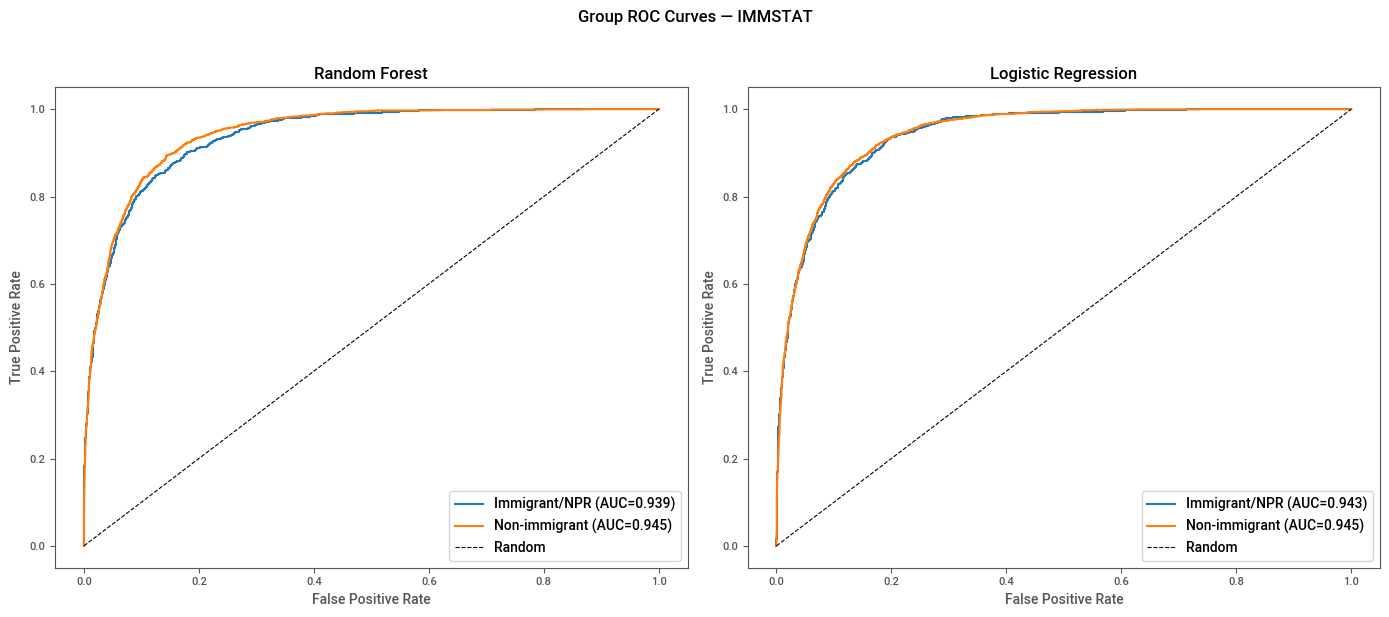

In [324]:
# IMMSTAT baseline
y_test_im  = y_test.loc[sens_im_test.index]
yp_rf_im   = pd.Series(y_pred_rf,  index=y_test.index).loc[sens_im_test.index].values
yp_lr_im   = pd.Series(y_pred_lr,  index=y_test.index).loc[sens_im_test.index].values
yprob_rf_im = pd.Series(y_prob_rf, index=y_test.index).loc[sens_im_test.index]
yprob_lr_im = pd.Series(y_prob_lr, index=y_test.index).loc[sens_im_test.index]

df_base_rf_im, sc_base_rf_im = fairness_metrics(y_test_im.values, yp_rf_im, sens_im_test, label="Random Forest (Baseline) | IMMSTAT", group_labels=immstat_labels)
df_base_lr_im, sc_base_lr_im = fairness_metrics(y_test_im.values, yp_lr_im, sens_im_test, label="Logistic Regression (Baseline) | IMMSTAT", group_labels=immstat_labels)

plot_group_roc([dict(y_true=y_test_im, y_prob=yprob_rf_im, sensitive=sens_im_test, title="Random Forest", group_labels=immstat_labels),
    dict(y_true=y_test_im, y_prob=yprob_lr_im, sensitive=sens_im_test, title="Logistic Regression", group_labels=immstat_labels),], main_title="Group ROC Curves — IMMSTAT")

## Technique 1: Reweighing

In [326]:
def compute_reweighing_weights(y_tr, s_tr):
    s  = np.array(s_tr)
    yt = np.array(y_tr)
    w  = np.ones(len(yt))
    for group in np.unique(s):
        for lbl in [0, 1]:
            mask = (s == group) & (yt == lbl)
            p_a, p_y, p_ay = (s==group).mean(), (yt==lbl).mean(), mask.mean()
            if p_ay > 0:
                w[mask] = (p_a * p_y) / p_ay
    return w

# Gender
w_gender = compute_reweighing_weights(y_train, G_train)
print("Mean weight per (Gender, label):")
print(pd.DataFrame({'gender': G_train.map(gender_labels).values,
                    'label':  y_train.values, 'weight': w_gender}).groupby(['gender','label'])['weight'].mean().unstack().round(4))

# IMMSTAT
y_train_im = y_train.loc[sens_im_train.index]
X_train_im = X_train.loc[sens_im_train.index]
X_train_im_scaled = scaler.transform(X_train_im)

w_immstat = compute_reweighing_weights(y_train_im, sens_im_train)
print("\nMean weight per (IMMSTAT, label):")
print(pd.DataFrame({'immstat': sens_im_train.map(immstat_labels).values,
                    'label':   y_train_im.values, 'weight': w_immstat}).groupby(['immstat','label'])['weight'].mean().unstack().round(4))

Mean weight per (Gender, label):
label        0       1
gender                
Man+    1.0802  0.7843
Woman+  0.9310  1.3779

Mean weight per (IMMSTAT, label):
label               0       1
immstat                      
Immigrant/NPR  0.9675  1.1421
Non-immigrant  1.0179  0.9390


Random Forest (Reweighted) | Gender threshold: 0.50
Logistic Regression (Reweighted) | Gender threshold: 0.46

─────────────────────────────────────────────────────────────────
  Random Forest (Reweighted) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8487  |  Balanced Accuracy: 0.8666
  DPD               : 0.0644
  EOD               : 0.0286
  PPD               : 0.2149
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2886  0.9034  0.1777     0.4783
Man+    7009         0.3530  0.8946  0.1491     0.6932


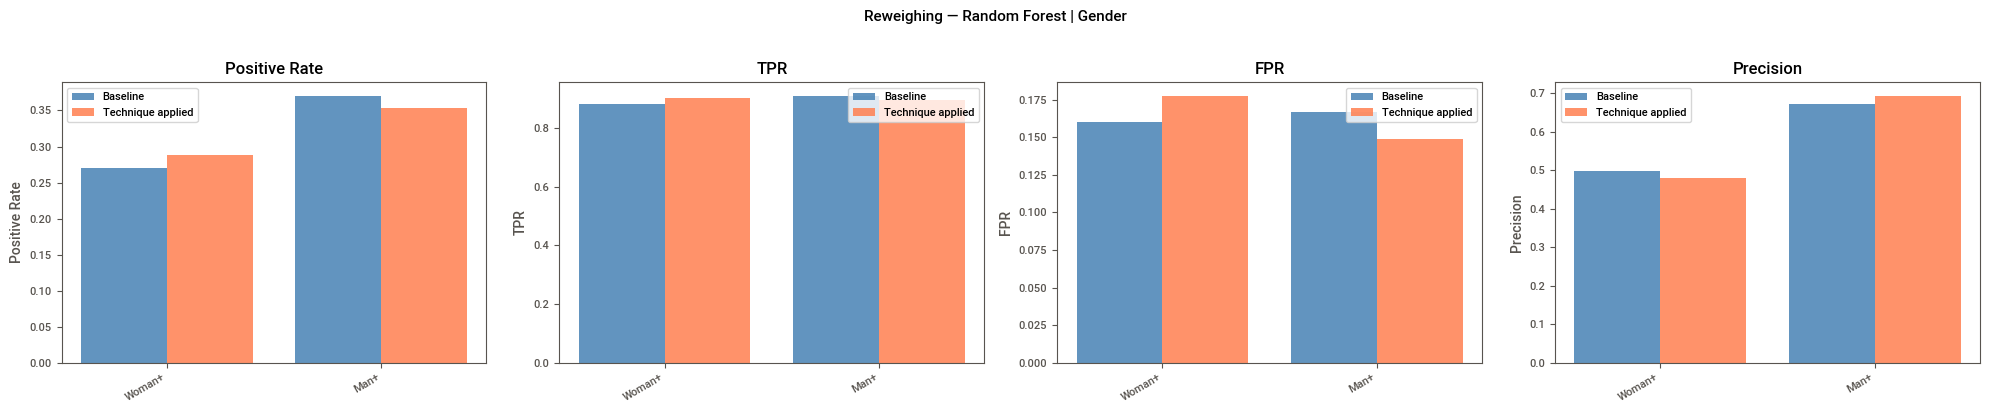

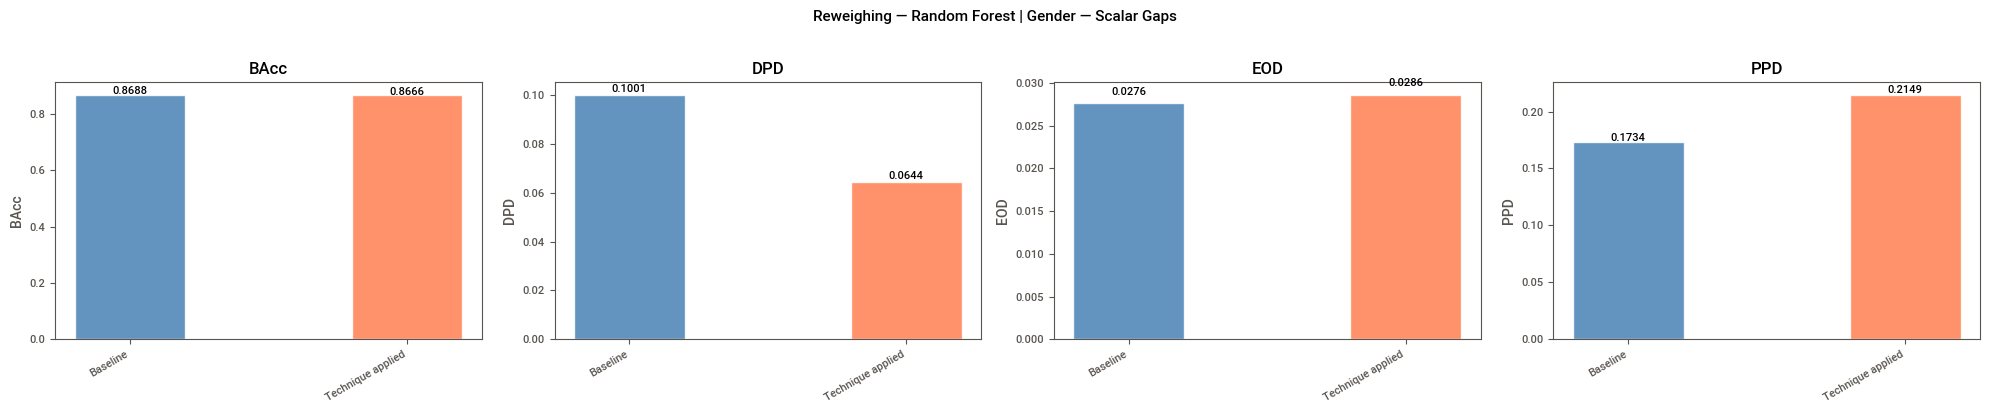


─────────────────────────────────────────────────────────────────
  Logistic Regression (Reweighted) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8530  |  Balanced Accuracy: 0.8704
  DPD               : 0.0767
  EOD               : 0.0211
  PPD               : 0.2112
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2794  0.8887  0.1696     0.4859
Man+    7009         0.3561  0.9077  0.1485     0.6971


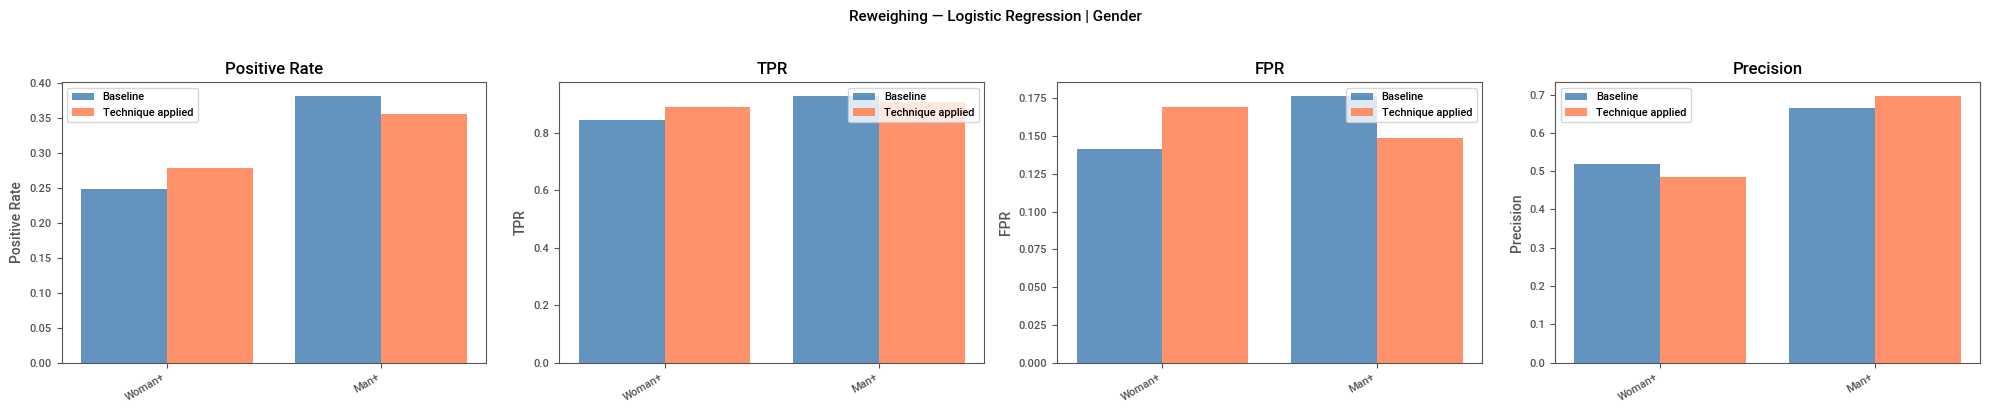

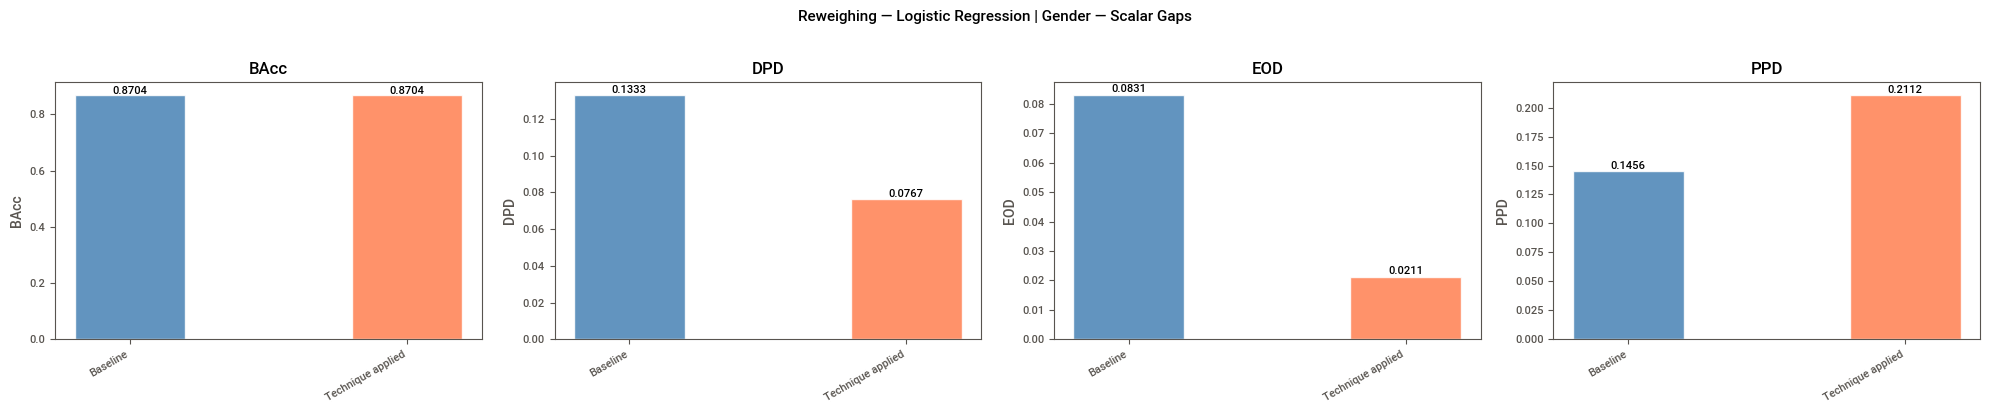

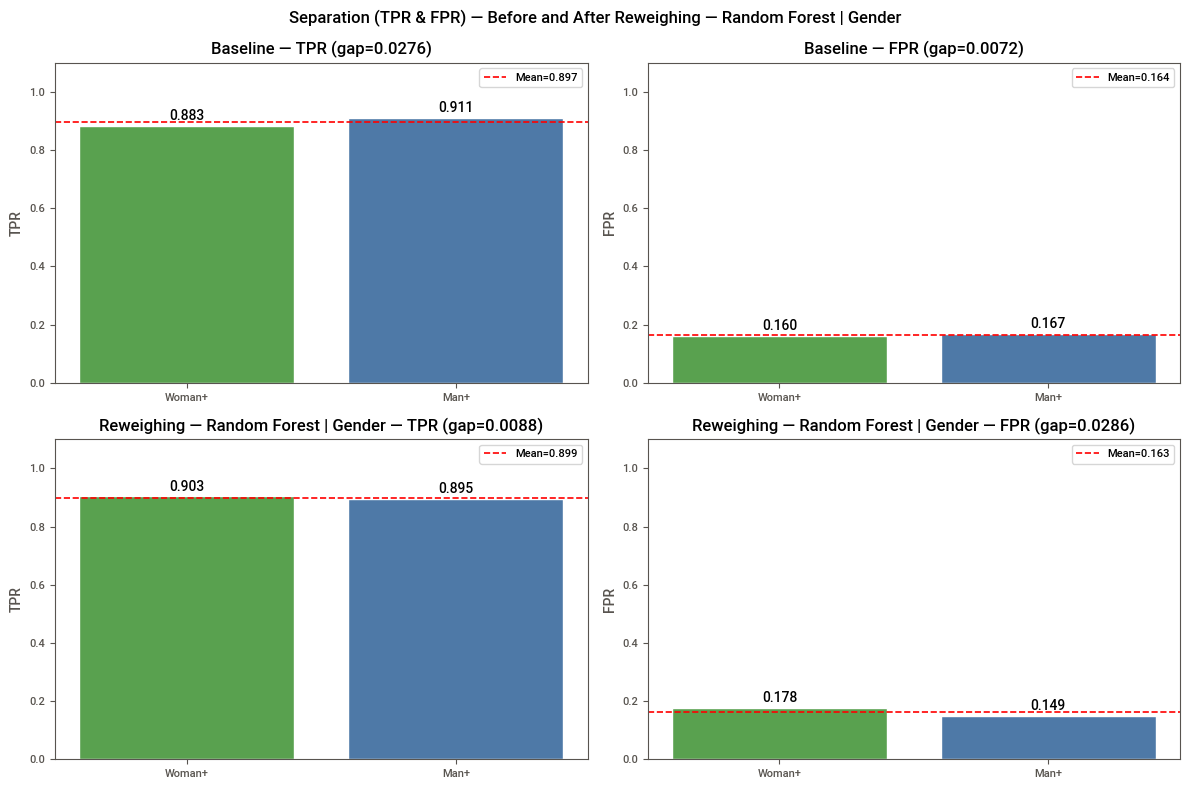

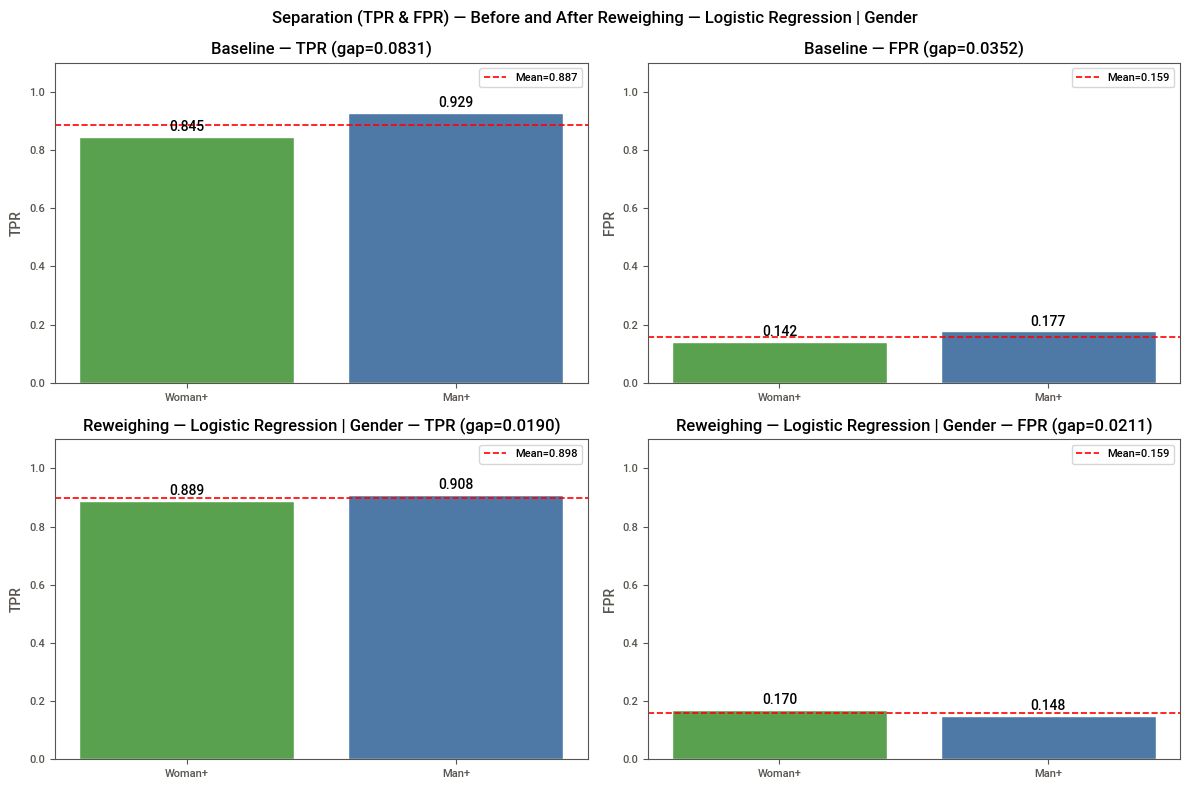

In [328]:
# Reweighted RF - Gender
rf_rw_g = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf_rw_g.fit(X_train, y_train, sample_weight=w_gender)
y_prob_rf_rw_g = rf_rw_g.predict_proba(X_test)[:, 1]

thr_rf_rw_g    = find_best_threshold(y_test, y_prob_rf_rw_g)
y_pred_rf_rw_g = (y_prob_rf_rw_g > thr_rf_rw_g).astype(int)
print(f"Random Forest (Reweighted) | Gender threshold: {thr_rf_rw_g:.2f}")

# Reweighed LR — Gender 
lr_rw_g = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_rw_g.fit(X_train_scaled, y_train, sample_weight=w_gender)
y_prob_lr_rw_g = lr_rw_g.predict_proba(X_test_scaled)[:, 1]

thr_lr_rw_g    = find_best_threshold(y_test, y_prob_lr_rw_g)
y_pred_lr_rw_g = (y_prob_lr_rw_g > thr_lr_rw_g).astype(int)
print(f"Logistic Regression (Reweighted) | Gender threshold: {thr_lr_rw_g:.2f}")

# Plot differences after reweighing
df_rw_rf_g, sc_rw_rf_g = fairness_metrics(y_test.values, y_pred_rf_rw_g, G_test, label="Random Forest (Reweighted) | Gender", group_labels=gender_labels)
plot_before_after(df_base_rf_g, df_rw_rf_g, METRICS, "Reweighing — Random Forest | Gender", sc_before=sc_base_rf_g, sc_after=sc_rw_rf_g)

df_rw_lr_g, sc_rw_lr_g = fairness_metrics(y_test.values, y_pred_lr_rw_g, G_test, label="Logistic Regression (Reweighted) | Gender", group_labels=gender_labels)
plot_before_after(df_base_lr_g, df_rw_lr_g, METRICS, "Reweighing — Logistic Regression | Gender", sc_before=sc_base_lr_g, sc_after=sc_rw_lr_g)

# TPR/FPR
plot_tpr_fpr_grid(y_test, y_pred_rf, y_pred_rf_rw_g, G_test, "Reweighing — Random Forest | Gender", group_labels=gender_labels)
plot_tpr_fpr_grid(y_test, y_pred_lr, y_pred_lr_rw_g, G_test, "Reweighing — Logistic Regression | Gender", group_labels=gender_labels)

Random Forest (Reweighted) | IMMSTAT threshold: 0.49
Logistic Regression (Reweighted) | IMMSTAT: 0.41

─────────────────────────────────────────────────────────────────
  Random Forest (Reweighted) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8449  |  Balanced Accuracy: 0.8692
  DPD               : 0.0407
  EOD               : 0.0226
  PPD               : 0.0669
                  N  Positive Rate     TPR     FPR  Precision
Group                                                        
Immigrant/NPR  4948         0.3038  0.8956  0.1704     0.5422
Non-immigrant  9150         0.3445  0.9182  0.1745     0.6091


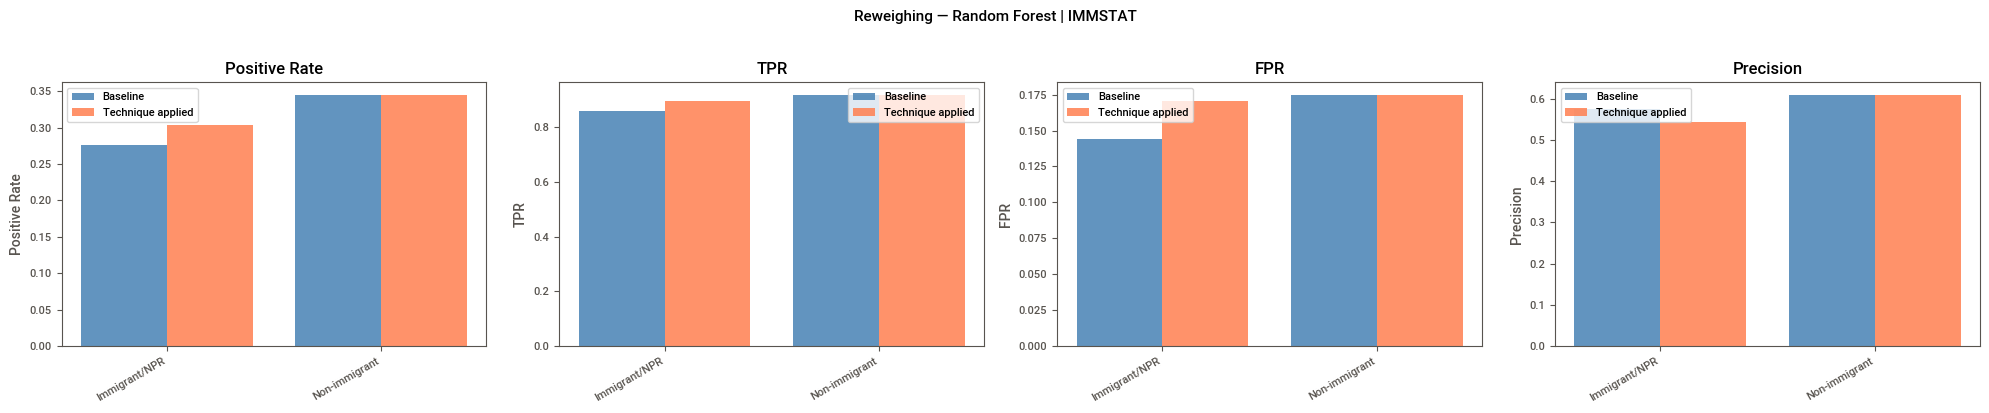

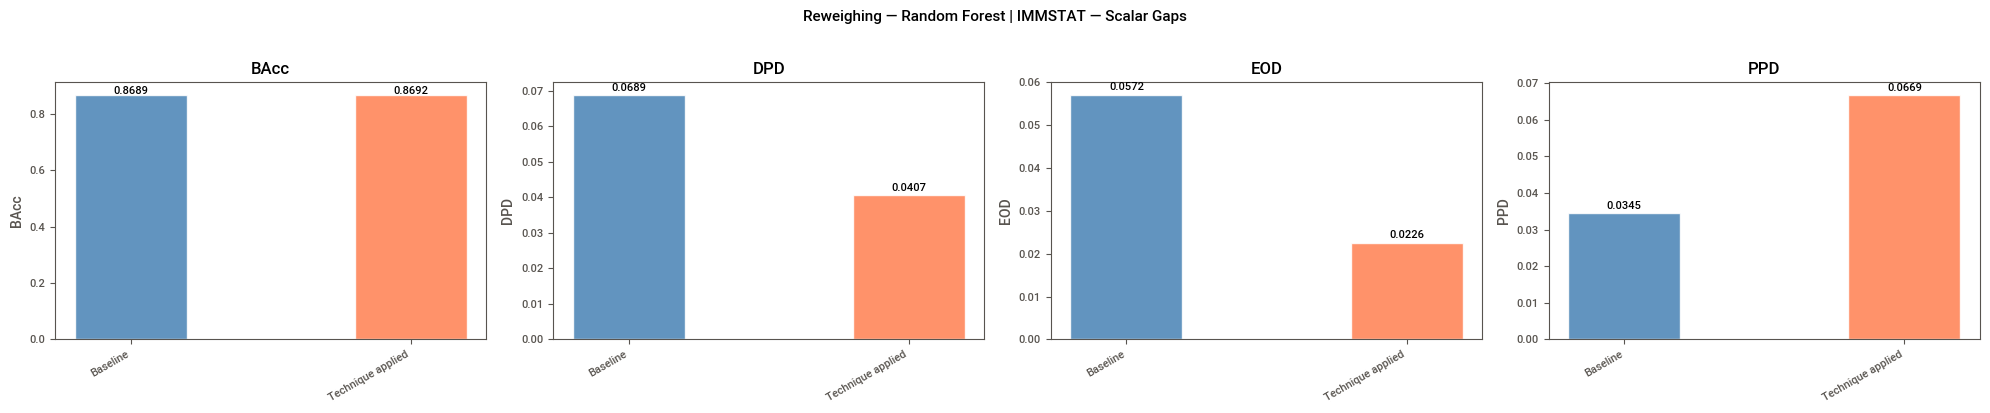


─────────────────────────────────────────────────────────────────
  Logistic Regression (Reweighted) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8449  |  Balanced Accuracy: 0.8702
  DPD               : 0.0419
  EOD               : 0.0159
  PPD               : 0.0609
                  N  Positive Rate     TPR     FPR  Precision
Group                                                        
Immigrant/NPR  4948         0.3044  0.9033  0.1694     0.5458
Non-immigrant  9150         0.3462  0.9192  0.1765     0.6067


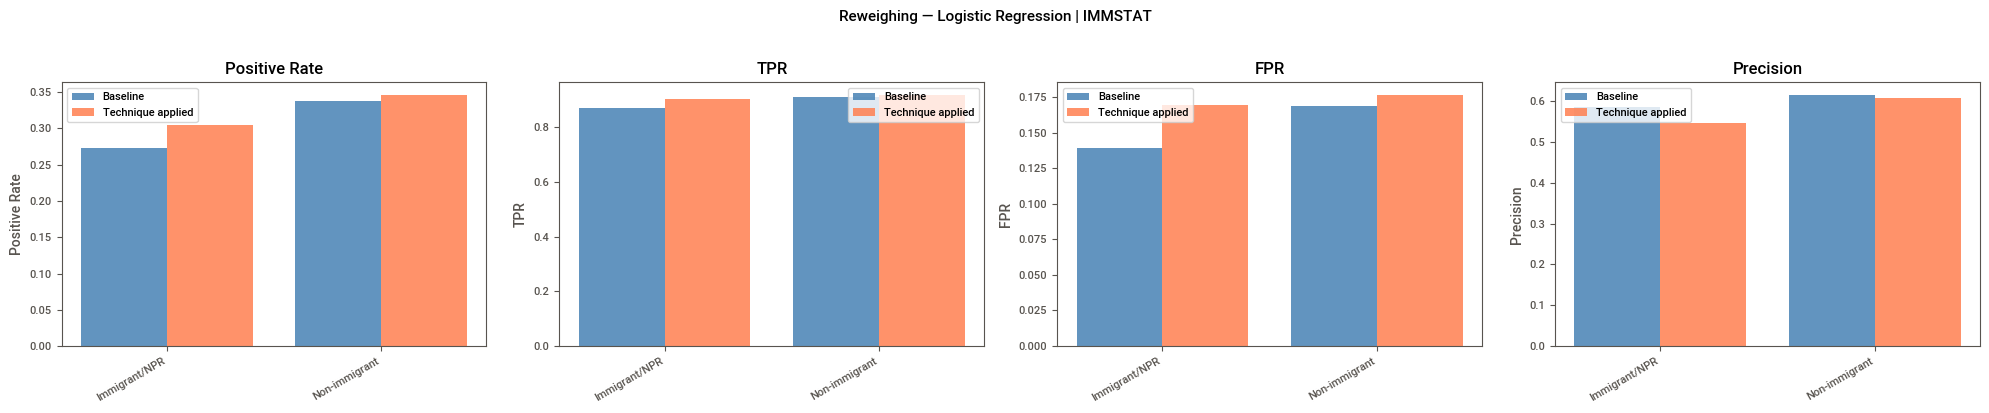

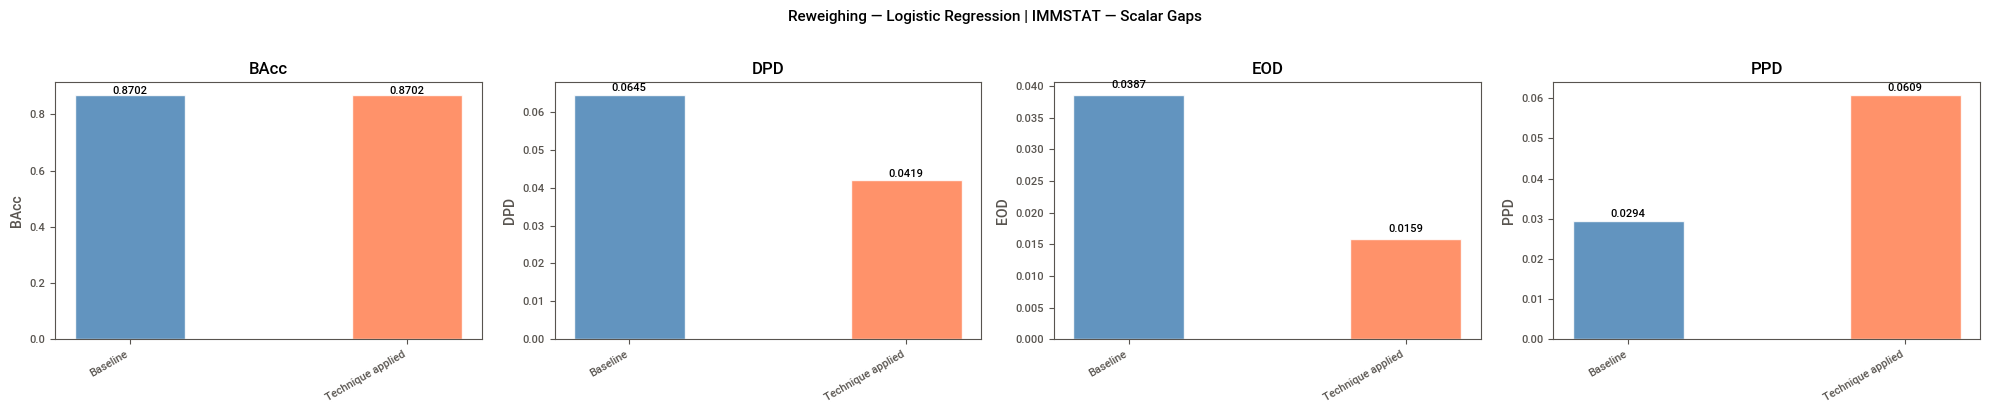

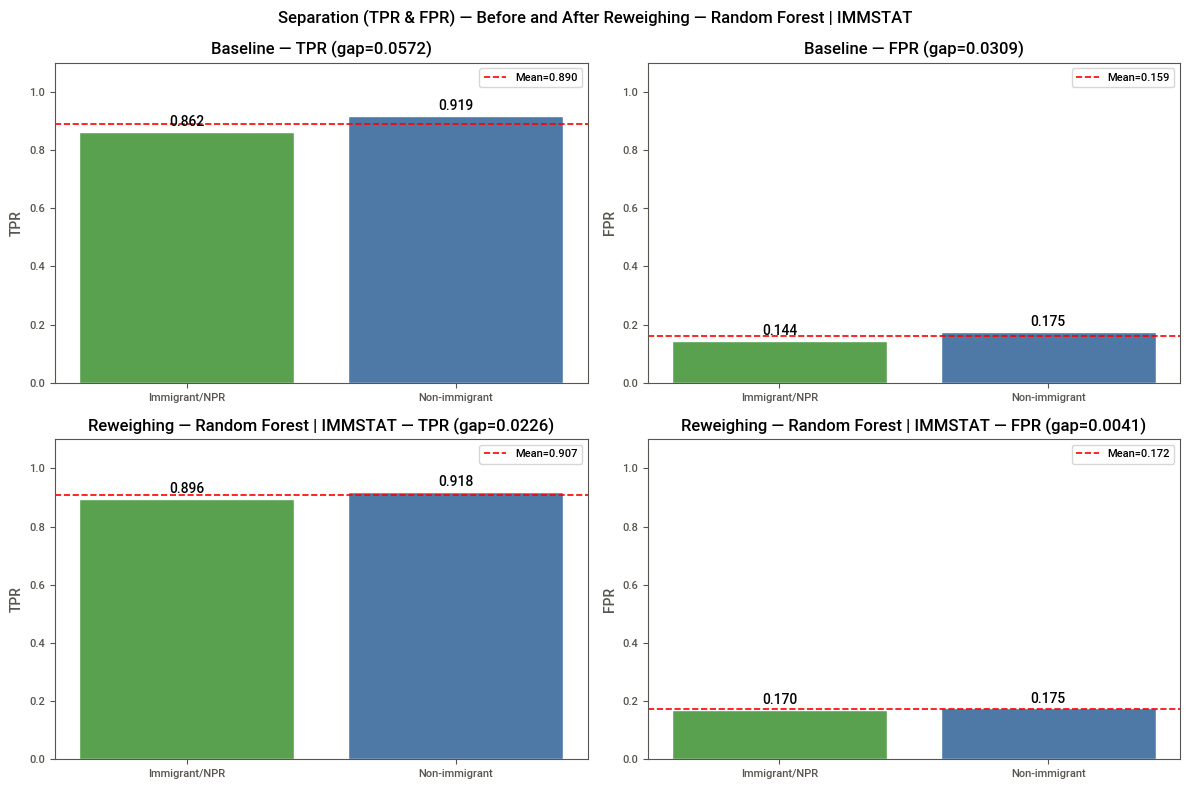

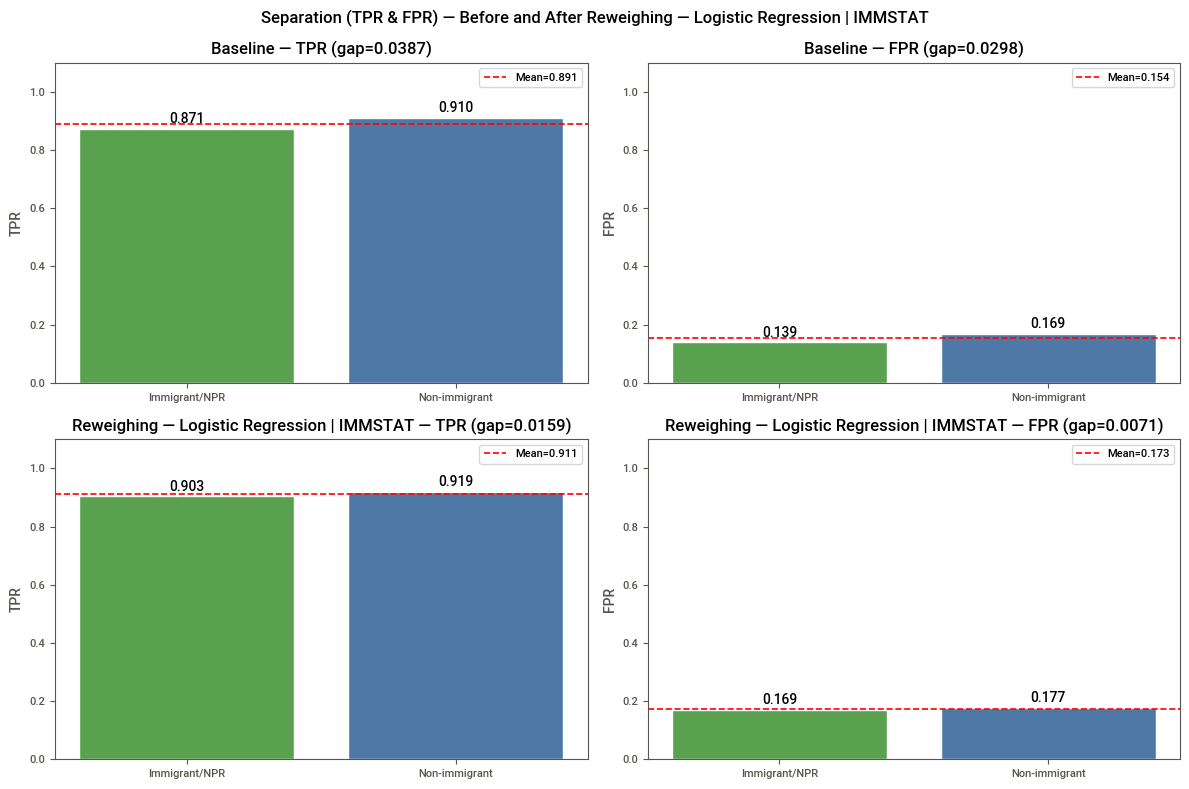

In [330]:
# Reweighed RF — IMMSTAT 
rf_rw_im = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf_rw_im.fit(X_train_im, y_train_im, sample_weight=w_immstat)
y_prob_rf_rw_im = rf_rw_im.predict_proba( X_test.loc[sens_im_test.index])[:, 1]

thr_rf_rw_im    = find_best_threshold(y_test_im, y_prob_rf_rw_im)
y_pred_rf_rw_im = (y_prob_rf_rw_im > thr_rf_rw_im).astype(int)
print(f"Random Forest (Reweighted) | IMMSTAT threshold: {thr_rf_rw_im:.2f}")

# Reweighed LR — IMMSTAT 
lr_rw_im = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_rw_im.fit(X_train_im_scaled, y_train_im, sample_weight=w_immstat)
y_prob_lr_rw_im = lr_rw_im.predict_proba(scaler.transform(X_test.loc[sens_im_test.index]))[:, 1]

thr_lr_rw_im    = find_best_threshold(y_test_im, y_prob_lr_rw_im)
y_pred_lr_rw_im = (y_prob_lr_rw_im > thr_lr_rw_im).astype(int)
print(f"Logistic Regression (Reweighted) | IMMSTAT: {thr_lr_rw_im:.2f}")

# Plotting output
df_rw_rf_im, sc_rw_rf_im = fairness_metrics(y_test_im.values, y_pred_rf_rw_im, sens_im_test, label="Random Forest (Reweighted) | IMMSTAT", group_labels=immstat_labels)
plot_before_after(df_base_rf_im, df_rw_rf_im, METRICS, "Reweighing — Random Forest | IMMSTAT", sc_before=sc_base_rf_im, sc_after=sc_rw_rf_im)

df_rw_lr_im, sc_rw_lr_im = fairness_metrics(y_test_im.values, y_pred_lr_rw_im, sens_im_test, label="Logistic Regression (Reweighted) | IMMSTAT", group_labels=immstat_labels)
plot_before_after(df_base_lr_im, df_rw_lr_im, METRICS, "Reweighing — Logistic Regression | IMMSTAT", sc_before=sc_base_lr_im, sc_after=sc_rw_lr_im)

# TPR / FPR
plot_tpr_fpr_grid(y_test_im, yp_rf_im, y_pred_rf_rw_im, sens_im_test, "Reweighing — Random Forest | IMMSTAT", group_labels=immstat_labels)
plot_tpr_fpr_grid(y_test_im, yp_lr_im, y_pred_lr_rw_im, sens_im_test, "Reweighing — Logistic Regression | IMMSTAT", group_labels=immstat_labels)

## Technique 2 - ThresholdOptimizer


─────────────────────────────────────────────────────────────────
  Random Forest (ThresholdOptimizer) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8514  |  Balanced Accuracy: 0.8616
  DPD               : 0.1001
  EOD               : 0.0154
  PPD               : 0.1611
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2602  0.8694  0.1503     0.5105
Man+    7009         0.3603  0.8847  0.1628     0.6717


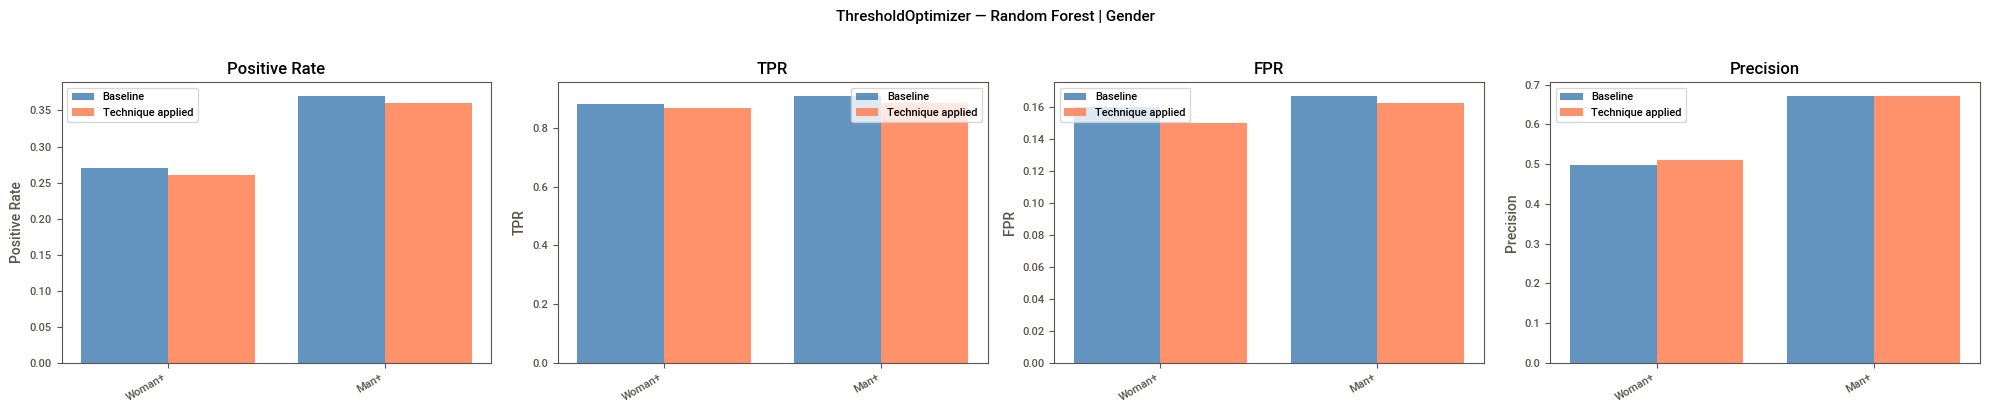

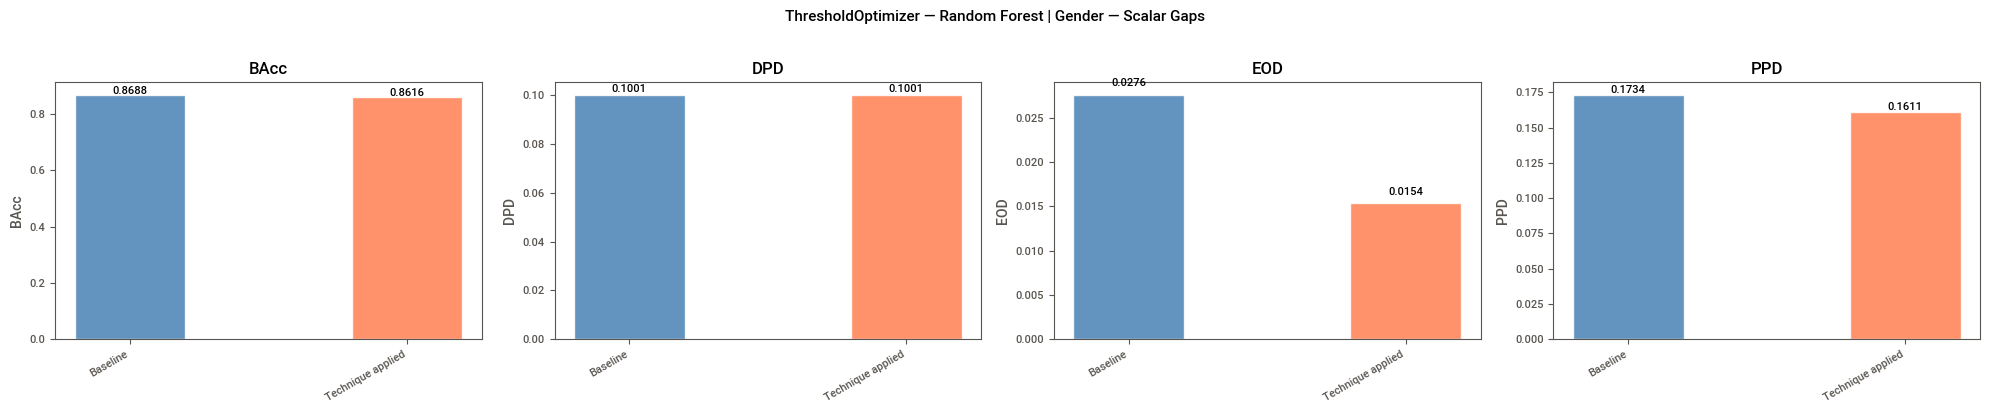


─────────────────────────────────────────────────────────────────
  Logistic Regression (ThresholdOptimizer) | Gender
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8463  |  Balanced Accuracy: 0.8580
  DPD               : 0.0928
  EOD               : 0.0080
  PPD               : 0.1702
           N  Positive Rate     TPR     FPR  Precision
Group                                                 
Woman+  7114         0.2685  0.8730  0.1594     0.4969
Man+    7009         0.3612  0.8811  0.1656     0.6671


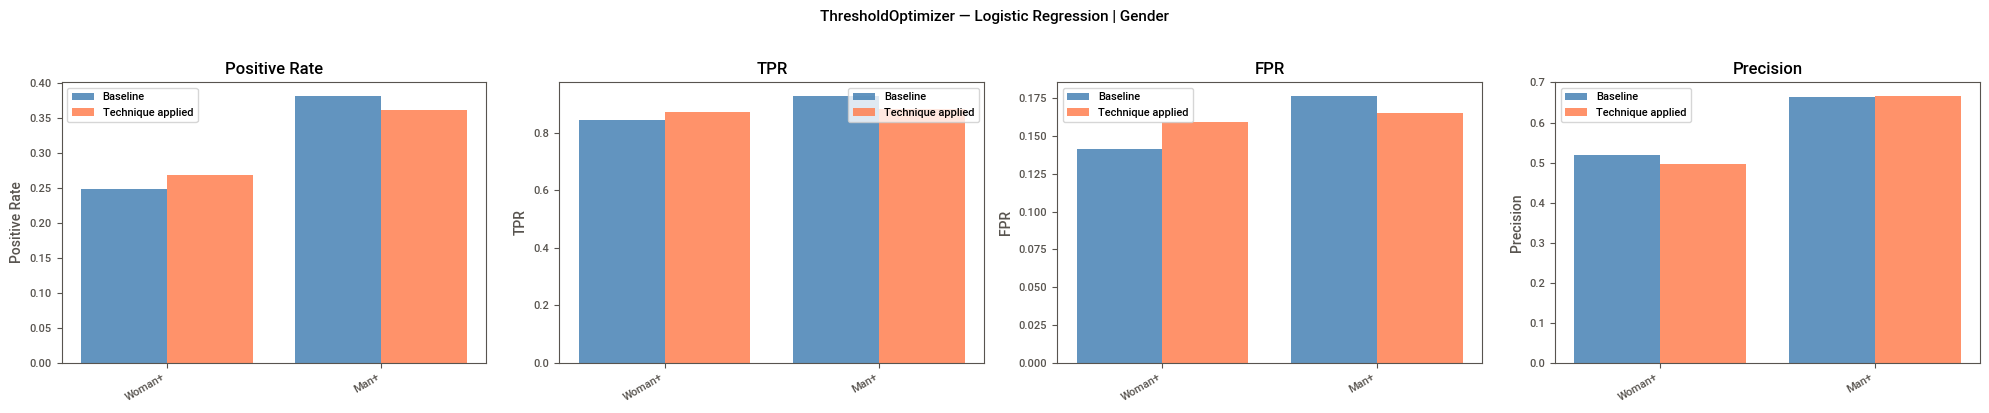

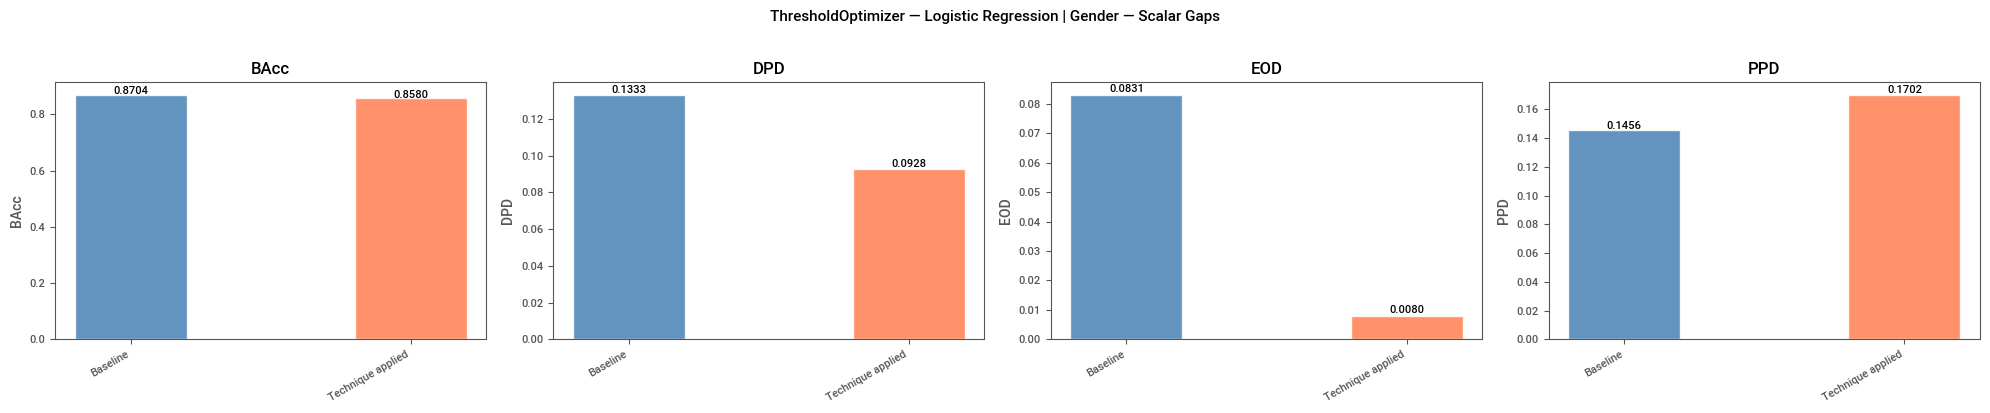

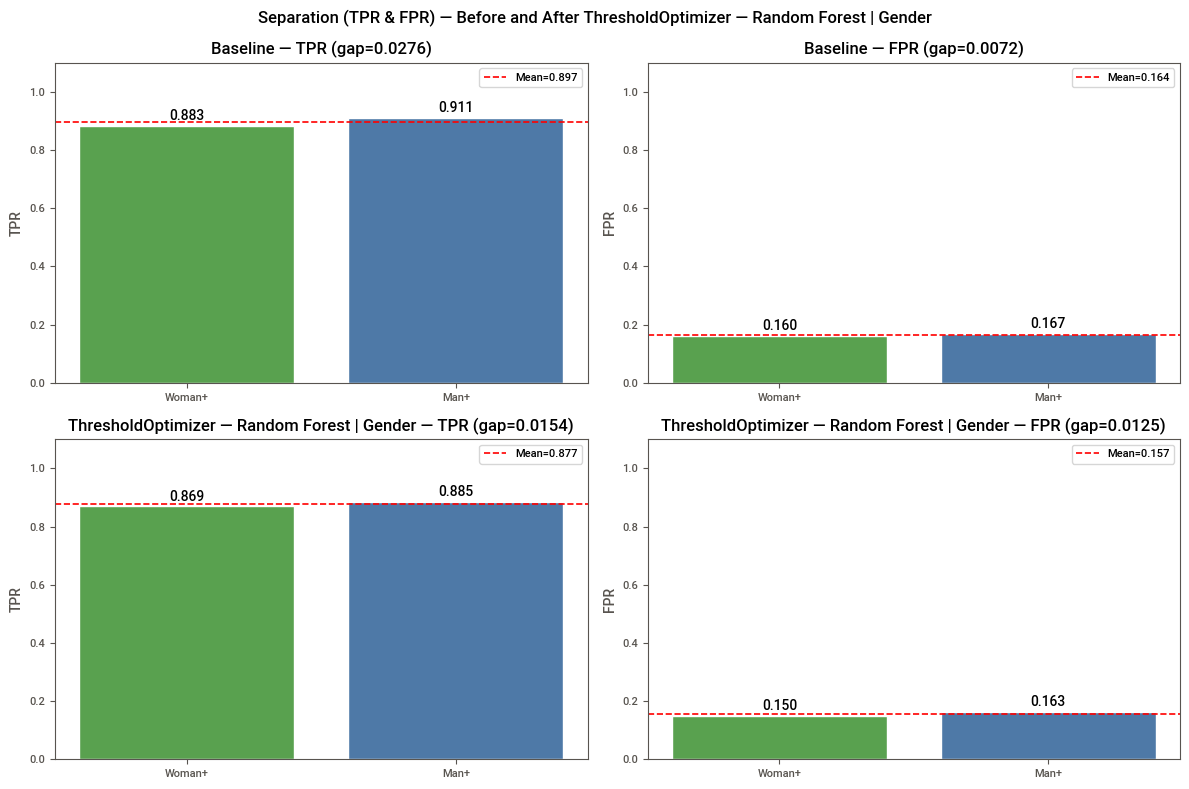

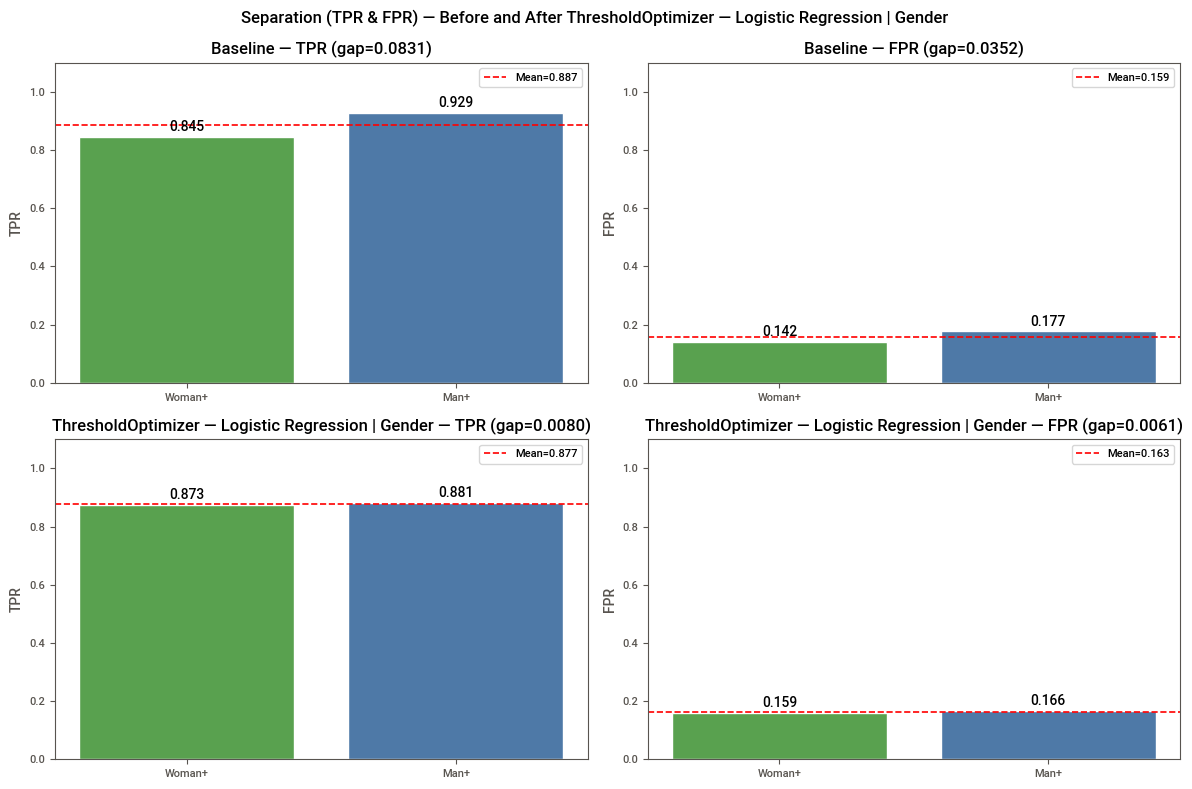

In [333]:
# ThresholdOptimizer — Gender 
to_rf_g = ThresholdOptimizer(estimator=rf, constraints="equalized_odds", objective="balanced_accuracy_score", predict_method="predict_proba")
to_rf_g.fit(X_train, y_train, sensitive_features=G_train)
y_pred_rf_to_g = to_rf_g.predict(X_test, sensitive_features=G_test)

to_lr_g = ThresholdOptimizer(estimator=lr_pipe, constraints="equalized_odds", objective="balanced_accuracy_score", predict_method="predict_proba")
to_lr_g.fit(X_train, y_train, sensitive_features=G_train)
y_pred_lr_to_g = to_lr_g.predict(X_test, sensitive_features=G_test)

# Plot output
df_to_rf_g, sc_to_rf_g = fairness_metrics(y_test.values, y_pred_rf_to_g, G_test,label="Random Forest (ThresholdOptimizer) | Gender", group_labels=gender_labels)
plot_before_after(df_base_rf_g, df_to_rf_g, METRICS, "ThresholdOptimizer — Random Forest | Gender", sc_before=sc_base_rf_g, sc_after=sc_to_rf_g)

df_to_lr_g, sc_to_lr_g = fairness_metrics(y_test.values, y_pred_lr_to_g, G_test, label="Logistic Regression (ThresholdOptimizer) | Gender", group_labels=gender_labels)
plot_before_after(df_base_lr_g, df_to_lr_g, METRICS, "ThresholdOptimizer — Logistic Regression | Gender", sc_before=sc_base_lr_g, sc_after=sc_to_lr_g)

# TPR/FPR
plot_tpr_fpr_grid(y_test, y_pred_rf, y_pred_rf_to_g, G_test, "ThresholdOptimizer — Random Forest | Gender", group_labels=gender_labels)
plot_tpr_fpr_grid(y_test, y_pred_lr, y_pred_lr_to_g, G_test, "ThresholdOptimizer — Logistic Regression | Gender", group_labels=gender_labels)


─────────────────────────────────────────────────────────────────
  Random Forest (ThresholdOptimizer) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8641  |  Balanced Accuracy: 0.8688
  DPD               : 0.0335
  EOD               : 0.0191
  PPD               : 0.0762
                  N  Positive Rate     TPR     FPR  Precision
Group                                                        
Immigrant/NPR  4948         0.2747  0.8637  0.1419     0.5784
Non-immigrant  9150         0.3082  0.8828  0.1380     0.6546


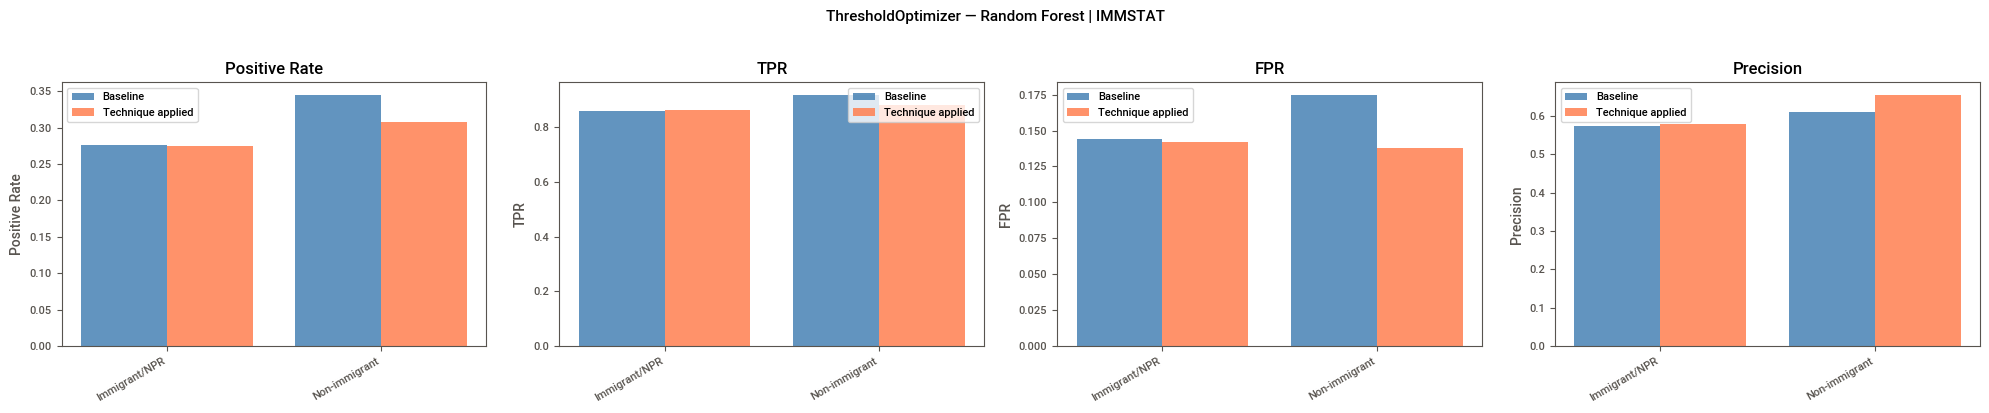

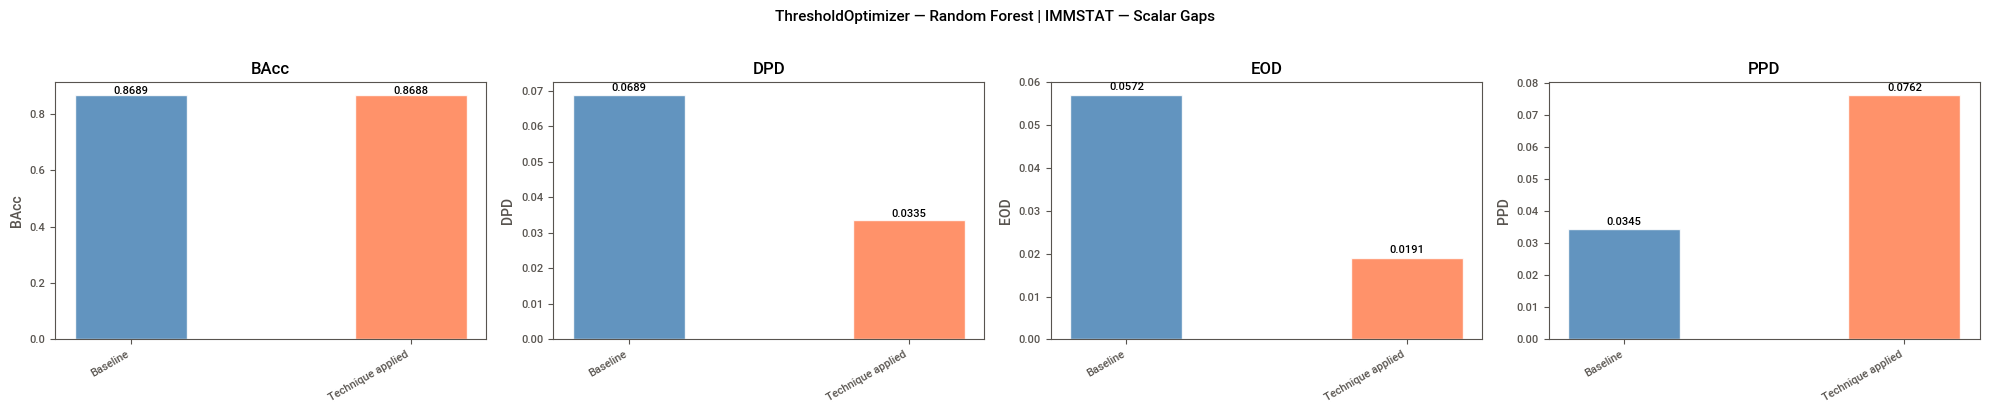

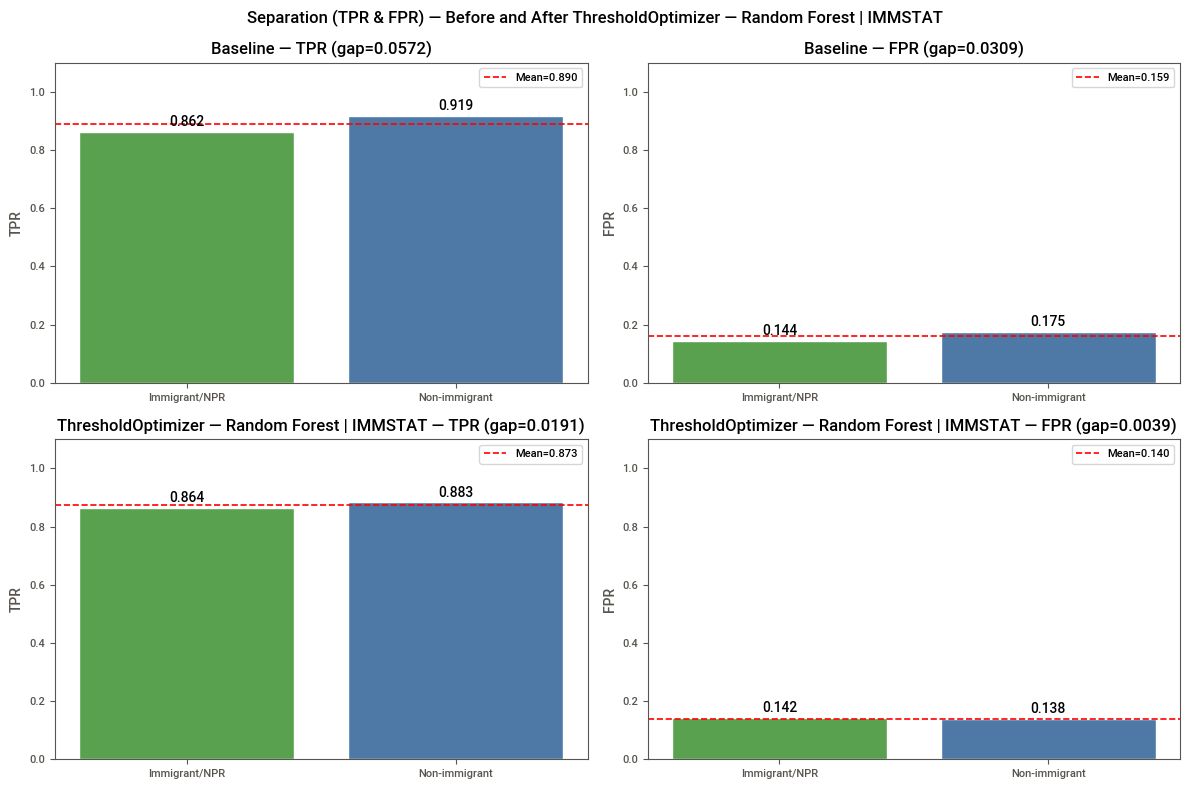


─────────────────────────────────────────────────────────────────
  Logistic Regression (ThresholdOptimizer) | IMMSTAT
─────────────────────────────────────────────────────────────────
  Accuracy          : 0.8583  |  Balanced Accuracy: 0.8691
  DPD               : 0.0416
  EOD               : 0.0218
  PPD               : 0.0624
                  N  Positive Rate     TPR     FPR  Precision
Group                                                        
Immigrant/NPR  4948         0.2797  0.8725  0.1461     0.5737
Non-immigrant  9150         0.3213  0.8943  0.1516     0.6361


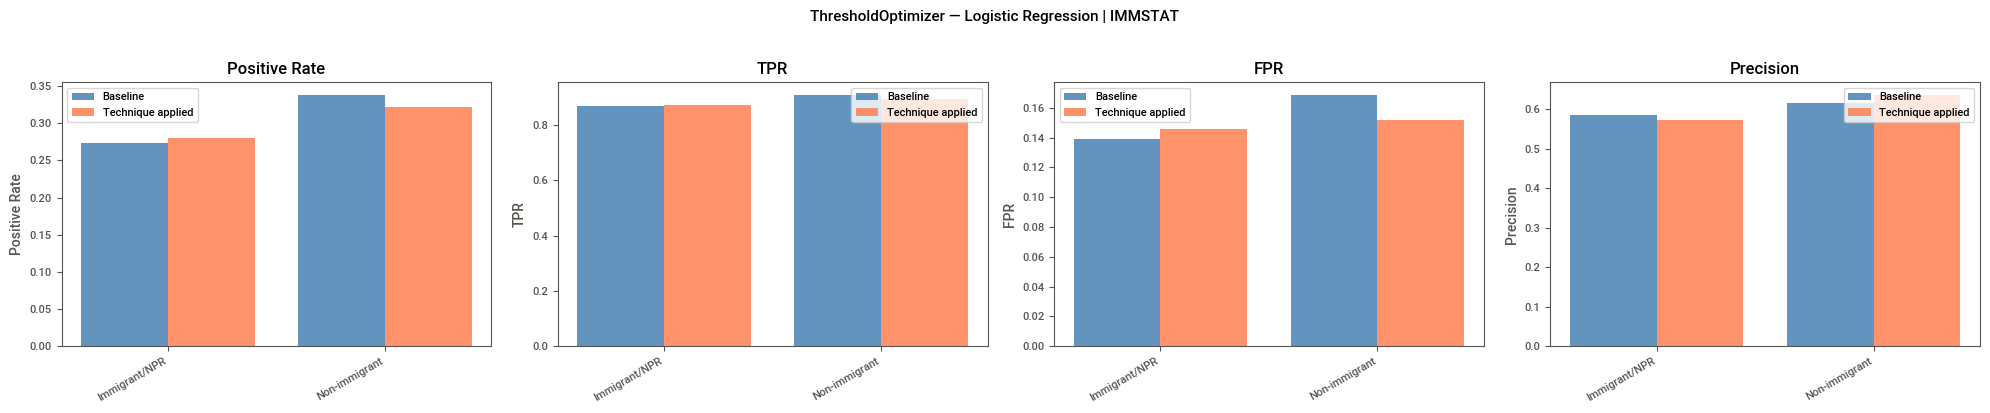

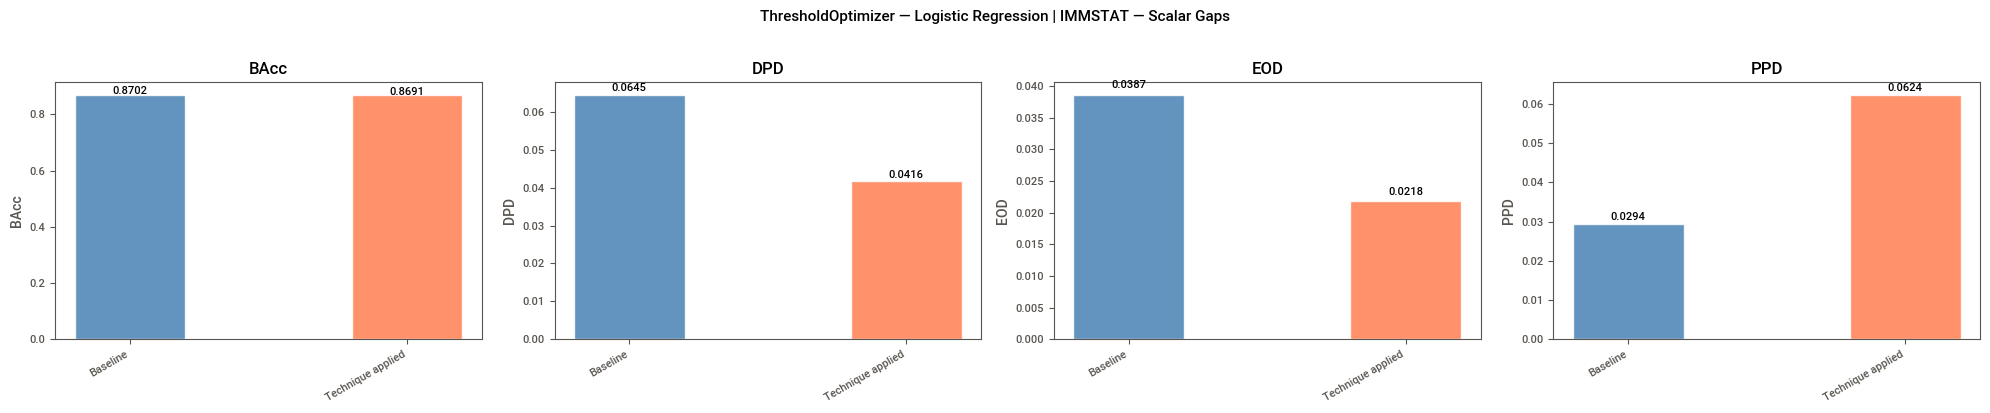

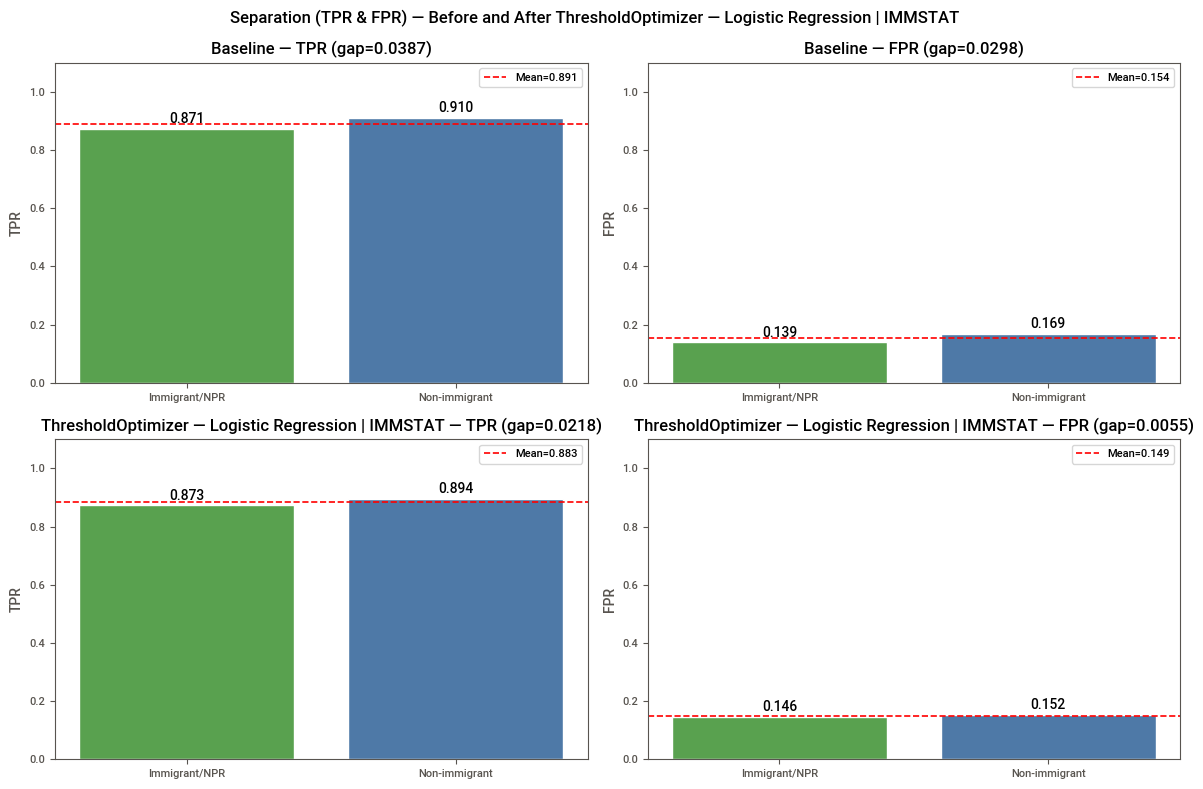

In [332]:
# ThresholdOptimizer — IMMSTAT | Random Forest
to_rf_im = ThresholdOptimizer(estimator=rf, constraints="equalized_odds", objective="balanced_accuracy_score", predict_method="predict_proba")
to_rf_im.fit(X_train_im, y_train_im, sensitive_features=sens_im_train)
y_pred_rf_to_im = to_rf_im.predict(X_test.loc[sens_im_test.index], sensitive_features=sens_im_test)

# Plot output
df_to_rf_im, sc_to_rf_im = fairness_metrics(y_test_im.values, y_pred_rf_to_im, sens_im_test, label="Random Forest (ThresholdOptimizer) | IMMSTAT", group_labels=immstat_labels)
plot_before_after(df_base_rf_im, df_to_rf_im, METRICS, "ThresholdOptimizer — Random Forest | IMMSTAT", sc_before=sc_base_rf_im, sc_after=sc_to_rf_im)

#TPR / FPR
plot_tpr_fpr_grid(y_test_im, yp_rf_im, y_pred_rf_to_im, sens_im_test,"ThresholdOptimizer — Random Forest | IMMSTAT", group_labels=immstat_labels)

# ThresholdOptimizer — IMMSTAT | Logistic Regression 
to_lr_im = ThresholdOptimizer(estimator=lr_pipe, constraints="equalized_odds", objective="balanced_accuracy_score", predict_method="predict_proba")
to_lr_im.fit(X_train_im, y_train_im, sensitive_features=sens_im_train)
y_pred_lr_to_im = to_lr_im.predict(X_test.loc[sens_im_test.index], sensitive_features=sens_im_test)

# Plot output
df_to_lr_im, sc_to_lr_im = fairness_metrics(y_test_im.values, y_pred_lr_to_im, sens_im_test, label="Logistic Regression (ThresholdOptimizer) | IMMSTAT", group_labels=immstat_labels)
plot_before_after(df_base_lr_im, df_to_lr_im, METRICS, "ThresholdOptimizer — Logistic Regression | IMMSTAT", sc_before=sc_base_lr_im, sc_after=sc_to_lr_im)

plot_tpr_fpr_grid(y_test_im, yp_lr_im, y_pred_lr_to_im, sens_im_test, "ThresholdOptimizer — Logistic Regression | IMMSTAT", group_labels=immstat_labels)

In [335]:
print_fairness_summary("Gender", G_test, [
    ('Random Forest', [
        ('Baseline',           y_test.values, y_pred_rf),
        ('Reweighing',         y_test.values, y_pred_rf_rw_g),
        ('ThresholdOptimizer', y_test.values, y_pred_rf_to_g),
    ]),
    ('Logistic Regression', [
        ('Baseline',           y_test.values, y_pred_lr),
        ('Reweighing',         y_test.values, y_pred_lr_rw_g),
        ('ThresholdOptimizer', y_test.values, y_pred_lr_to_g),
    ]),
])

print_fairness_summary("IMMSTAT", sens_im_test, [
    ('Random Forest', [
        ('Baseline',           y_test_im.values, yp_rf_im),
        ('Reweighing',         y_test_im.values, y_pred_rf_rw_im),
        ('ThresholdOptimizer', y_test_im.values, y_pred_rf_to_im),
    ]),
    ('Logistic Regression', [
        ('Baseline',           y_test_im.values, yp_lr_im),
        ('Reweighing',         y_test_im.values, y_pred_lr_rw_im),
        ('ThresholdOptimizer', y_test_im.values, y_pred_lr_to_im),
    ]),
])


SUMMARY: All fairness metrics — Gender, Random Forest
Method                         Acc     BAcc      DPD      EOD      PPD
----------------------------------------------------------------------
Baseline                    0.8504   0.8688   0.1001   0.0276   0.1734
Reweighing                  0.8487   0.8666   0.0644   0.0286   0.2149
ThresholdOptimizer          0.8514   0.8616   0.1001   0.0154   0.1611


SUMMARY: All fairness metrics — Gender, Logistic Regression
Method                         Acc     BAcc      DPD      EOD      PPD
----------------------------------------------------------------------
Baseline                    0.8543   0.8704   0.1333   0.0831   0.1456
Reweighing                  0.8530   0.8704   0.0767   0.0211   0.2112
ThresholdOptimizer          0.8463   0.8580   0.0928   0.0080   0.1702


SUMMARY: All fairness metrics — IMMSTAT, Random Forest
Method                         Acc     BAcc      DPD      EOD      PPD
---------------------------------------------

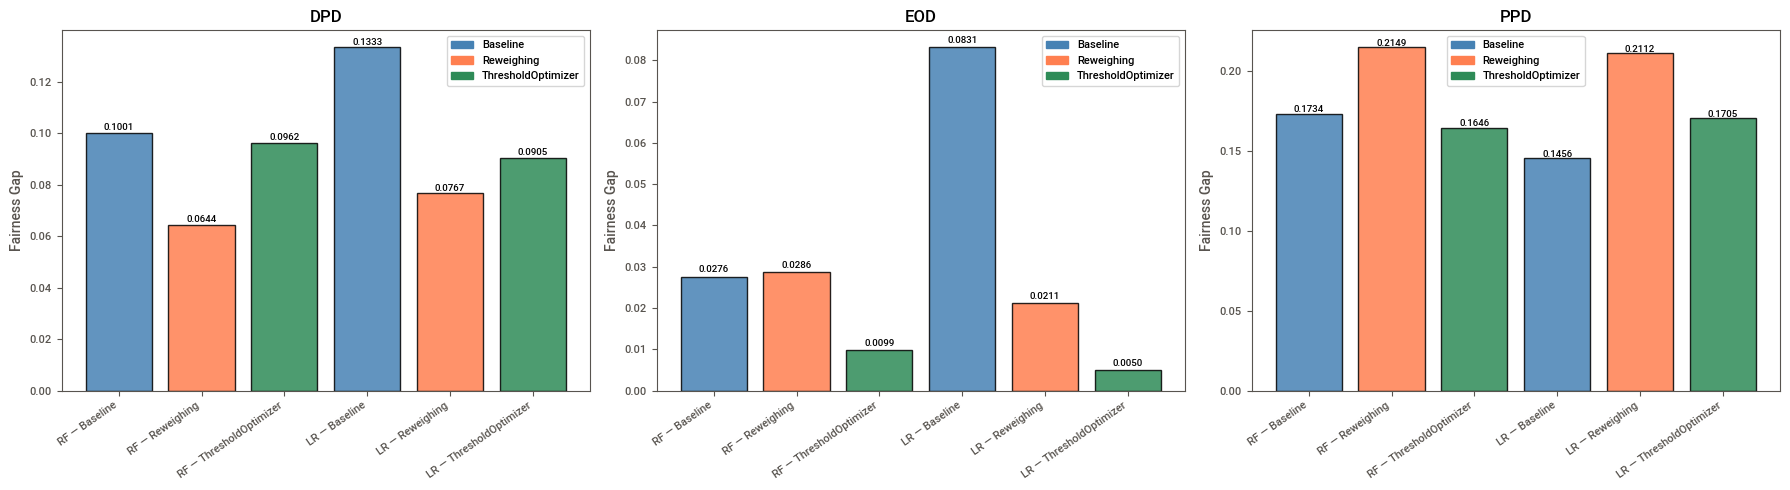

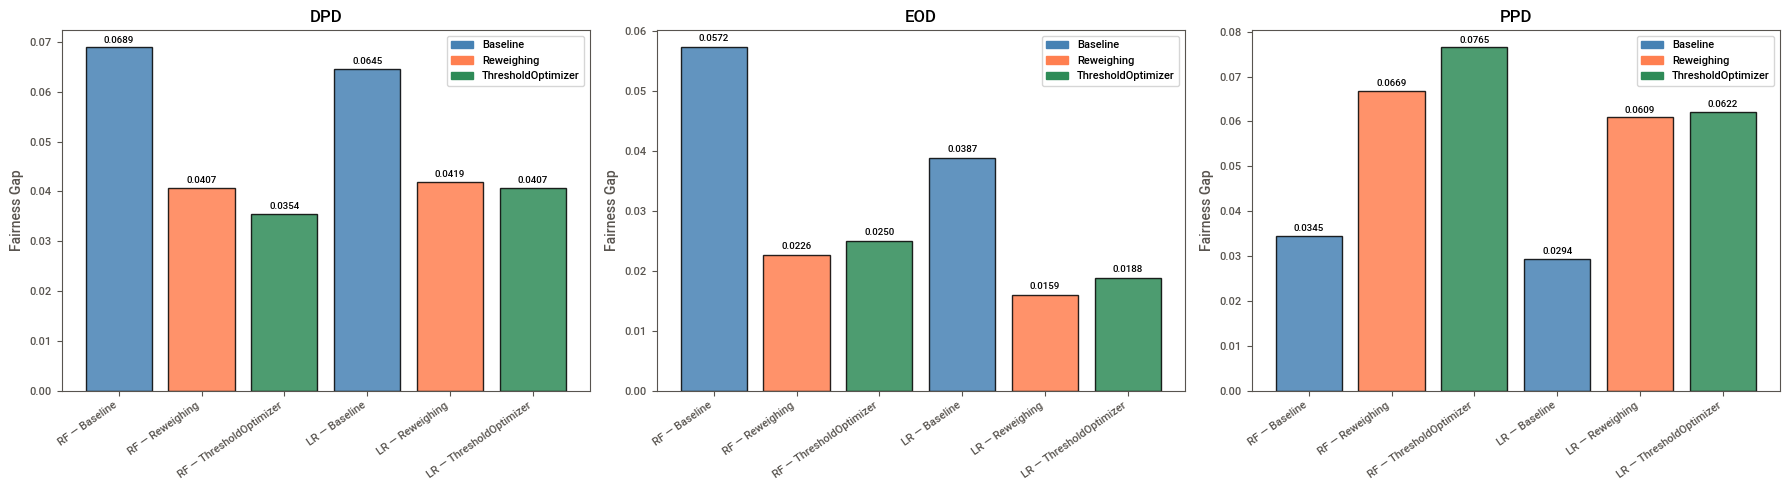

In [336]:
fairness_gap_plot(summ_g, "Fairness Gap Summary — Gender")
fairness_gap_plot(summ_im, "Fairness Gap Summary — IMMSTAT")